In [1]:
#activate venv: 

import pandas as pd
import time
#other requirements: sklearn, matplotlib, statsmodels

In [2]:
start=time.perf_counter()

In [3]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLRunningAveragesCalculator import FPLRunningAveragesCalculator

current_season = 20252026
current_gw = 23

start=time.perf_counter()

if __name__ == "__main__":
    #Run Database Creator
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Initialize the calculator
    calculator = FPLRunningAveragesCalculator(db_creator)
    
    # Define metrics to average
    metrics = [
        'minutes', 'total_points', 'team_elo', 'opp_team_elo',
        'goals_scored', 'bonus', 'bps', 'clean_sheets', 'goals_conceded',
        'expected_goals', 'expected_assists', 'expected_goal_involvements',
        'expected_goals_conceded', 'cbi', 'defensive_contribution',
        'recoveries', 'tackles', 'saves'
    ]
    
    # Define interaction pairs
    interaction_pairs = [
        ('expected_goal_involvements', 'defensive_contribution'),
    ]
    
    # Calculate running averages
    df = calculator.calculate(
        metrics_to_average=metrics,
        window_sizes=[3, 5, 10],
        include_alltime=True,
        include_per_90=True,
        include_raw=True,
        include_elo_adjusted=True,
        include_squared_per_90=True,
        interaction_pairs=interaction_pairs
    )

    # Identify columns to exclude from forward filling (all fpl playergwdf columns) real life data columns
    exclude_cols = ['player_name_id', 'season', 'event',
                    'fixture', 'total_points', 'minutes',
                    'goals_scored', 'assists', 'team_elo', 'opp_team_elo',
                    'position', 'bonus', 'bps', 'clean_sheets',
                    'goals_conceded', 'was_home', 'expected_assists',
                    'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded',
                    'starts', 'team_name', 'opp_team_name',
                    'cbi','defensive_contribution','recoveries','tackles'
                    'saves']

    # Create a mask for rows to fill: season 20252026 and event > 10
    mask = (df['season'] == current_season) & (df['event'] > current_gw)

    # Get columns to fill
    cols_to_fill = [col for col in df.columns if col not in exclude_cols]

    # Sort by player and event to ensure proper order
    df = df.sort_values(['season', 'player_name_id', 'event'])

    # Forward fill only for the masked rows
    df_filled = df.copy()

    for col in cols_to_fill:
        # Forward fill within each player group
        df_filled.loc[mask, col] = df_filled.groupby('player_name_id')[col].ffill()[mask]

    table_name = "playergw_transformed"
    db_creator.create_staging_table_then_insert_data(table_name, data=df_filled)
    playergw_transformed = db_creator.table_to_df(table_name=table_name)
    
    finish=time.perf_counter()
    print("playergw_transformed inserted into psql")
    print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
    print(playergw_transformed.info())

playergw_transformed inserted into psql
Finished in 24.68 minute(s)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148512 entries, 0 to 148511
Columns: 431 entries, player_name_id to saves_elo_p90sq_10
dtypes: float64(426), object(5)
memory usage: 488.3+ MB
None


In [4]:
from DatabaseCreator import DatabaseCreator
import CJDH_local_settings
from FPLPredictor import FPLPredictor

#add this info to a settings dict?
stats_current_gameweek = current_gw
picks_current_gameweek = current_gw
# current_season = 20252026

cbi_defcon_cols = [
    'cbi_at',
    'cbi_p90_at',
    'cbi_3',
    'cbi_p90_3',
    'cbi_elo_3',
    'cbi_elo_p90_3',
    'cbi_5',
    'cbi_p90_5',
    'cbi_elo_5',
    'cbi_elo_p90_5',
    'cbi_10',
    'cbi_p90_10',
    'cbi_elo_10',
    'cbi_elo_p90_10',
    'defensive_cont_at',
    'defensive_cont_p90_at',
    'defensive_cont_3',
    'defensive_cont_p90_3',
    'defensive_cont_elo_3',
    'defensive_cont_elo_p90_3',
    'defensive_cont_5',
    'defensive_cont_p90_5',
    'defensive_cont_elo_5',
    'defensive_cont_elo_p90_5',
    'defensive_cont_10',
    'defensive_cont_p90_10',
    'defensive_cont_elo_10',
    'defensive_cont_elo_p90_10',
    'saves_at',
    'saves_p90_at',
    'saves_3',
    'saves_p90_3',
    'saves_elo_3',
    'saves_elo_p90_3',
    'saves_5',
    'saves_p90_5',
    'saves_elo_5',
    'saves_elo_p90_5',
    'saves_10',
    'saves_p90_10',
    'saves_elo_10',
    'saves_elo_p90_10',
    'recoveries_at',
    'recoveries_p90_at',
    'recoveries_3',
    'recoveries_p90_3',
    'recoveries_elo_3',
    'recoveries_elo_p90_3',
    'recoveries_5',
    'recoveries_p90_5',
    'recoveries_elo_5',
    'recoveries_elo_p90_5',
    'recoveries_10',
    'recoveries_p90_10',
    'recoveries_elo_10',
    'recoveries_elo_p90_10',
    'tackles_at',
    'tackles_p90_at',
    'tackles_3',
    'tackles_p90_3',
    'tackles_elo_3',
    'tackles_elo_p90_3',
    'tackles_5',
    'tackles_p90_5',
    'tackles_elo_5',
    'tackles_elo_p90_5',
    'tackles_10',
    'tackles_p90_10',
    'tackles_elo_10',
    'tackles_elo_p90_10'
]

#Run Database Creator
if __name__ == "__main__":
    db_creator = DatabaseCreator(db_settings=CJDH_local_settings.local_settings['FPL_Points_Predictor'])
    fpl_engine = db_creator.get_engine_for("fpl_data_analysis")

    # Load df from sql
    df = db_creator.run_sql("""SELECT *
                            FROM playergw_transformed
                            """)
    print("=" * 80)
    print("Checking NaN Summary")
    print("=" * 80)

    temp_filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)
    temp_predictor = FPLPredictor(
        data=df[temp_filtered],
        target='expected_goals_per90',
        positions={'FWD', 'MID','DEF'},
        columns_to_drop=cbi_defcon_cols
    )
    nan_summary = temp_predictor.get_nan_summary()

Checking NaN Summary

NaN Summary for 288 potential features:
Total rows: 39647

Features with NaN values:
                                       feature  nan_count  nan_pct  non_null_count
                            recoveries_p90sq_3      35498    89.54            4149
                        recoveries_elo_p90sq_3      35498    89.54            4149
                               tackles_p90sq_3      35498    89.54            4149
                           tackles_elo_p90sq_3      35498    89.54            4149
                                   cbi_p90sq_3      35498    89.54            4149
                               cbi_elo_p90sq_3      35498    89.54            4149
                        defensive_cont_p90sq_3      35498    89.54            4149
                    defensive_cont_elo_p90sq_3      35498    89.54            4149
                               tackles_p90sq_5      35465    89.45            4182
                           tackles_elo_p90sq_5      35465    89

In [5]:
df[(df['season']==current_season)
   &(df['team_name']=='Arsenal')
   &(df['event']>15)
   &(df['player_name_id']=='Bukayo Saka')
   ][['player_name_id','event','total_points','opp_team_name','xgoals_p90sq_at']].sort_values(by='event')

,player_name_id,event,total_points,opp_team_name,xgoals_p90sq_at
132210,Bukayo Saka,16.0,11.0,Wolves,0.375133
132212,Bukayo Saka,17.0,3.0,Everton,0.371668
132214,Bukayo Saka,18.0,7.0,Brighton,0.369029
132216,Bukayo Saka,19.0,6.0,Aston Villa,0.369398
132218,Bukayo Saka,20.0,4.0,Bournemouth,0.367637
132220,Bukayo Saka,21.0,3.0,Liverpool,0.364410
132223,Bukayo Saka,22.0,1.0,Nott'm Forest,0.361389
132226,Bukayo Saka,23.0,2.0,Man Utd,0.359322
132229,Bukayo Saka,24.0,NaN,Leeds,0.356240
132231,Bukayo Saka,25.0,NaN,Sunderland,0.356240


In [6]:
# #restricts to player_name_id who have >0 minutes in that season
# #model struggles to predict higher values, so maybe cut-off points at 10, or try log(points) as a depvar
# for each indepvar: filter outliers & standardize

In [7]:
# #Optimizing hyperparameters

# filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['expected_goals']>0)

# if __name__ == "__main__":

#     print("\n" + "=" * 80)
#     print("FWD xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)
    
#     FWD_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'FWD'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     FWD_xG_predictor.fit()
#     FWD_xG_predictor.plot_cv_results()
    
#     # Get best parameters in grid format
#     FWD_params_grid = FWD_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     FWD_xG_errors = FWD_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("MID xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     MID_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'MID'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300] # cannot be larger than sample size!
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     MID_xG_predictor.fit()
#     MID_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     MID_params_grid = MID_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     MID_xG_errors = MID_xG_predictor.get_largest_errors(return_full_data=True)

#     print("\n" + "=" * 80)
#     print("DEF xG Predictor with GridSearch Optimization and NaN Filtering")
#     print("=" * 80)

#     DEF_xG_predictor = FPLPredictor(
#         data=df[filtered],
#         target='expected_goals_per90',
#         positions={'DEF'},
#         columns_to_drop=cbi_defcon_cols,
#         optimize=True,  # Enable GridSearchCV
#         param_grid={
#             'n_estimators': [200],
#             'max_depth': [20, 30, 50],
#             'min_samples_split': [50, 100, 200, 300]
#         },
#         cv_folds=5,
#         max_nan_pct=10  # Remove features with >10% NaN values
#     )
#     DEF_xG_predictor.fit()
#     DEF_xG_predictor.plot_cv_results()

#     # Get best parameters in grid format
#     DEF_params_grid = DEF_xG_predictor.get_best_params_as_grid()
#     #Get largest errors
#     DEF_xG_errors = DEF_xG_predictor.get_largest_errors(return_full_data=True)


In [8]:
# print(FWD_params_grid)
# print(MID_params_grid)
# print(DEF_params_grid)

In [9]:
FWD_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
MID_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}
DEF_params_grid = {'max_depth': [30], 'min_samples_split': [200], 'n_estimators': [200]}

In [10]:
# target=expected_goals_per90, FWD_xG_predictor
# Cleaned df size: 2450/4170

# Performing GridSearchCV hyperparameter optimization...
# Parameter grid: {'n_estimators': [200], 'max_depth': [20, 30, 50], 'min_samples_split': [500]}
# Cross-validation folds: 5
# Fitting 5 folds for each of 3 candidates, totalling 15 fits

# Best parameters found:
#   max_depth: 20
#   min_samples_split: 500
#   n_estimators: 200

# Best CV RMSE: 0.4231

# Training Set Performance:
# R² Score: 0.1823
# RMSE: 0.4056
# MAE: 0.2978

# Test Set Performance:
# R² Score: 0.1273
# RMSE: 0.4301
# MAE: 0.3197

Cleaned df size: 2278/7329

Training Set Performance:
R² Score: 0.8361
RMSE: 13.2398
MAE: 10.9400

Test Set Performance:
R² Score: 0.4074
RMSE: 25.7769
MAE: 21.4649

Top 20 Feature Importances:
                  feature  importance
                minutes_3    0.219340
            minutes_elo_3    0.082346
     opp_team_elo_p90sq_3    0.034550
         team_elo_p90sq_3    0.015762
    opp_team_elo_p90sq_at    0.014120
        team_elo_p90sq_at    0.011628
         team_elo_p90sq_5    0.010643
    opp_team_elo_p90sq_10    0.009834
        team_elo_p90sq_10    0.009816
             opp_team_elo    0.008954
  opp_team_elo_elo_p90_10    0.008371
           opp_team_elo_5    0.008176
    clean_sheets_p90sq_at    0.008104
 opp_team_elo_elo_p90sq_3    0.008005
                 elo_diff    0.007996
opp_team_elo_elo_p90sq_10    0.007668
     opp_team_elo_p90sq_5    0.007384
             bps_p90sq_at    0.007274
                 team_elo    0.007170
        minutes_elo_p90_5    0.007163


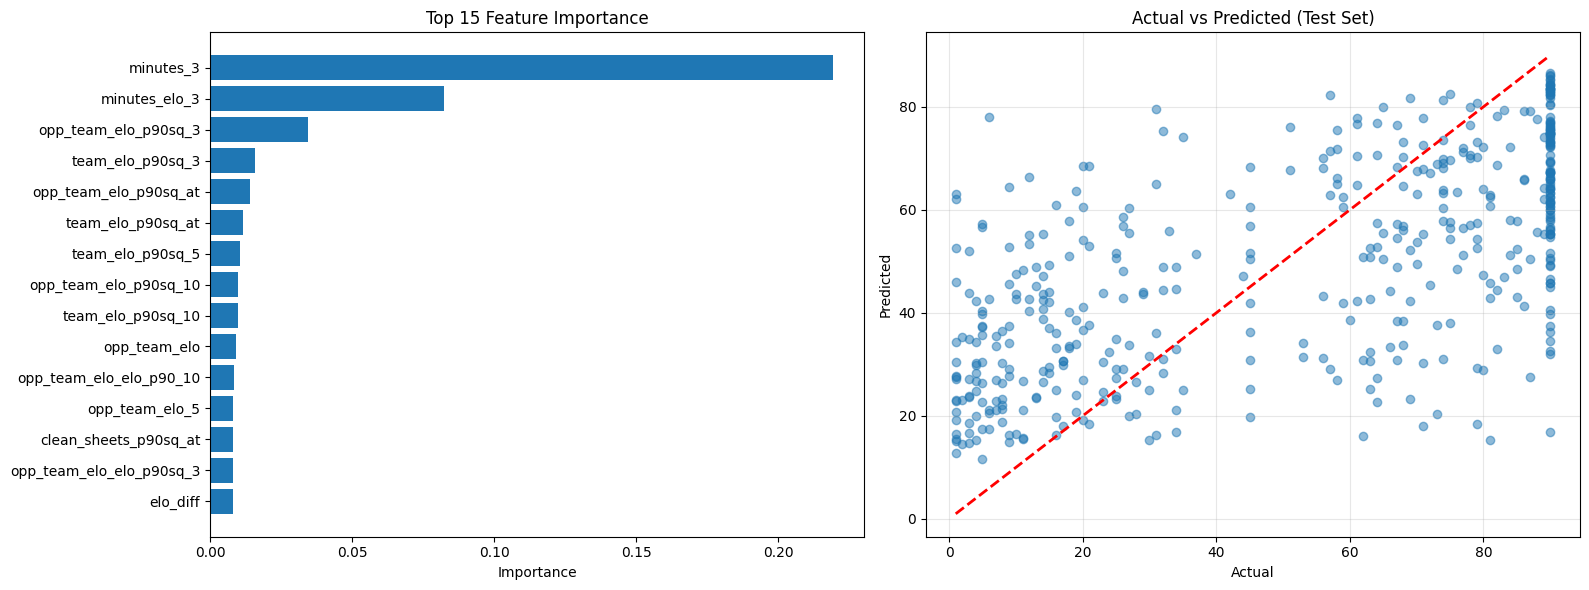

Cleaned df size: 7908/27423

Training Set Performance:
R² Score: 0.6702
RMSE: 18.5208
MAE: 15.2903

Test Set Performance:
R² Score: 0.3216
RMSE: 26.4319
MAE: 21.8077

Top 20 Feature Importances:
              feature  importance
            minutes_3    0.341748
               bps_10    0.027088
        minutes_elo_3    0.020562
 opp_team_elo_p90sq_3    0.018732
opp_team_elo_p90sq_10    0.015355
           minutes_10    0.011732
 opp_team_elo_p90sq_5    0.009375
         opp_team_elo    0.009184
    minutes_elo_p90_5    0.008806
      xg_over_g_ratio    0.008789
            minutes_5    0.007596
       minutes_elo_10    0.007549
opp_team_elo_p90sq_at    0.007516
             elo_diff    0.007424
goals_scored_p90sq_at    0.007002
    team_elo_p90sq_10    0.006974
goals_conceded_elo_10    0.006944
      opp_team_elo_10    0.006749
clean_sheets_p90sq_at    0.006415
       bonus_p90sq_at    0.006338


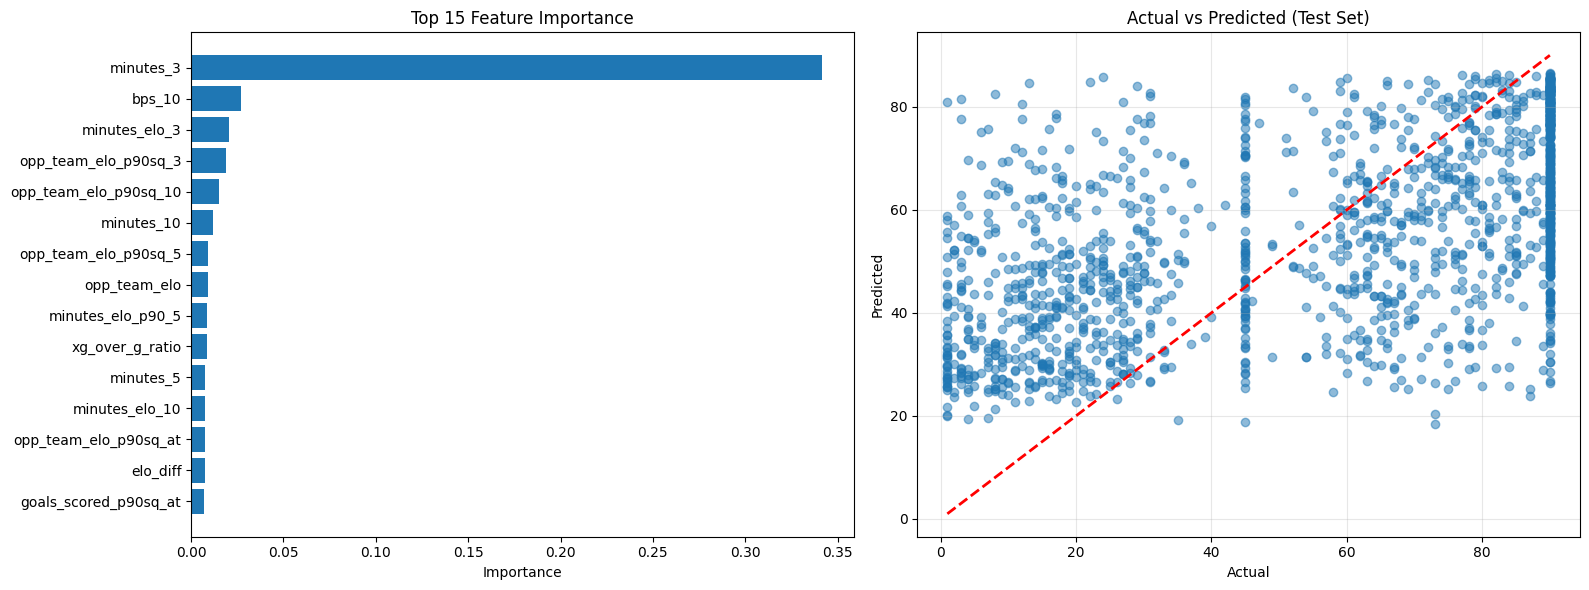

Cleaned df size: 4945/19735

Training Set Performance:
R² Score: 0.6841
RMSE: 16.5556
MAE: 12.3680

Test Set Performance:
R² Score: 0.1875
RMSE: 27.0935
MAE: 20.1187

Top 20 Feature Importances:
                 feature  importance
               minutes_3    0.177812
    opp_team_elo_p90sq_3    0.045953
        team_elo_p90sq_3    0.039026
   opp_team_elo_p90sq_10    0.019947
           minutes_elo_3    0.011159
         xg_over_g_ratio    0.010818
         opp_team_elo_10    0.010666
opp_team_elo_elo_p90sq_3    0.010564
          opp_team_elo_3    0.010563
  opp_team_elo_elo_p90_5    0.010166
            opp_team_elo    0.010013
       team_elo_p90sq_10    0.009971
    opp_team_elo_p90sq_5    0.009759
        team_elo_p90sq_5    0.009451
       xassists_p90sq_at    0.009172
 goals_conceded_p90sq_at    0.009124
                elo_diff    0.008686
              minutes_10    0.008610
            bps_p90sq_at    0.008375
          opp_team_elo_5    0.008348


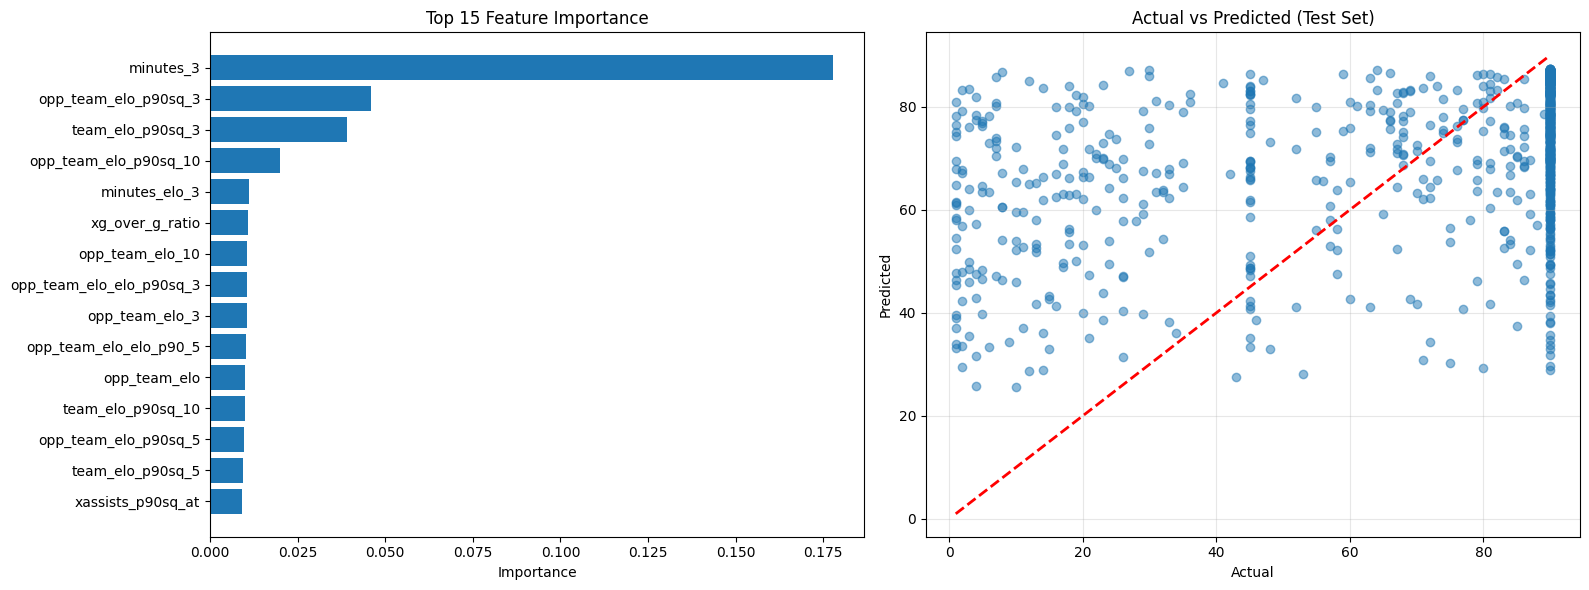

Cleaned df size: 3821/4082

Training Set Performance:
R² Score: 0.7148
RMSE: 2.8466
MAE: 0.5827

Test Set Performance:
R² Score: -0.0817
RMSE: 4.4575
MAE: 1.0396

Top 20 Feature Importances:
                feature  importance
  opp_team_elo_p90sq_at    0.052475
         team_elo_elo_3    0.041865
           opp_team_elo    0.035513
           bps_p90sq_at    0.034526
         opp_team_elo_5    0.026950
                 bps_10    0.026507
            bps_p90sq_3    0.024816
          minutes_elo_3    0.023550
      saves_elo_p90sq_3    0.020244
         opp_team_elo_3    0.018015
               elo_diff    0.017627
  total_points_p90sq_at    0.017389
        opp_team_elo_10    0.016790
            bps_p90sq_5    0.016509
         saves_p90sq_10    0.015939
      saves_elo_p90sq_5    0.014737
     saves_elo_p90sq_10    0.014430
  opp_team_elo_p90sq_10    0.013923
goals_conceded_p90sq_at    0.013370
      team_elo_p90sq_at    0.012307


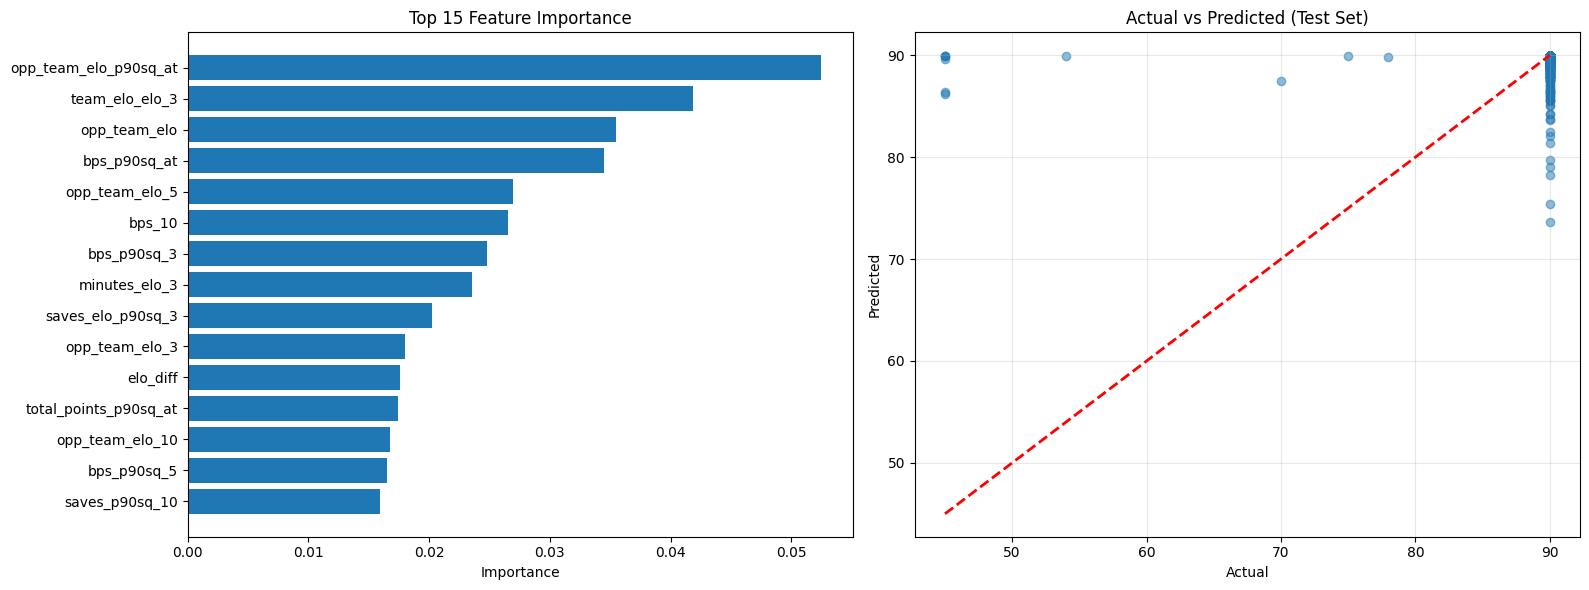

In [11]:
mins_filter = (df['player_season_minutes_total']>100)&(df['minutes']>0)

if __name__ == "__main__":
    
    FWD_mins_predictor = FPLPredictor(
                data=df[mins_filter],
        target='minutes',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=50
        )
    FWD_mins_predictor.fit()
    FWD_mins_predictor.plot_results()

    MID_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=50
        )
    MID_mins_predictor.fit()
    MID_mins_predictor.plot_results()

    DEF_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=50
        )
    DEF_mins_predictor.fit()
    DEF_mins_predictor.plot_results()

    GK_mins_predictor = FPLPredictor(
        data=df[mins_filter],
        target='minutes',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10
        )
    GK_mins_predictor.fit()
    GK_mins_predictor.plot_results()

target=expected_goals_per90, FWD_xG_predictor
Cleaned df size: 2493/4213

Training Set Performance:
R² Score: 0.5892
RMSE: 0.2537
MAE: 0.2016

Test Set Performance:
R² Score: 0.0123
RMSE: 0.3664
MAE: 0.2845

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.050900
    goals_scored_p90sq_at    0.037255
          xg_over_g_ratio    0.022884
             opp_team_elo    0.020608
         team_elo_p90sq_3    0.015882
           bonus_p90sq_at    0.015298
           opp_team_elo_5    0.015097
           opp_team_elo_3    0.014610
    total_points_p90sq_at    0.014082
          opp_team_elo_10    0.013687
     opp_team_elo_p90sq_3    0.013679
         team_elo_p90sq_5    0.013338
total_points_elo_p90sq_10    0.013019
 goals_scored_elo_p90sq_3    0.012023
      total_points_p90_10    0.010851
    total_points_p90sq_10    0.010729
  goals_conceded_p90sq_at    0.010551
     opp_team_elo_p90sq_5    0.009937
    clean_sheets_p90sq_at    0.009589
    

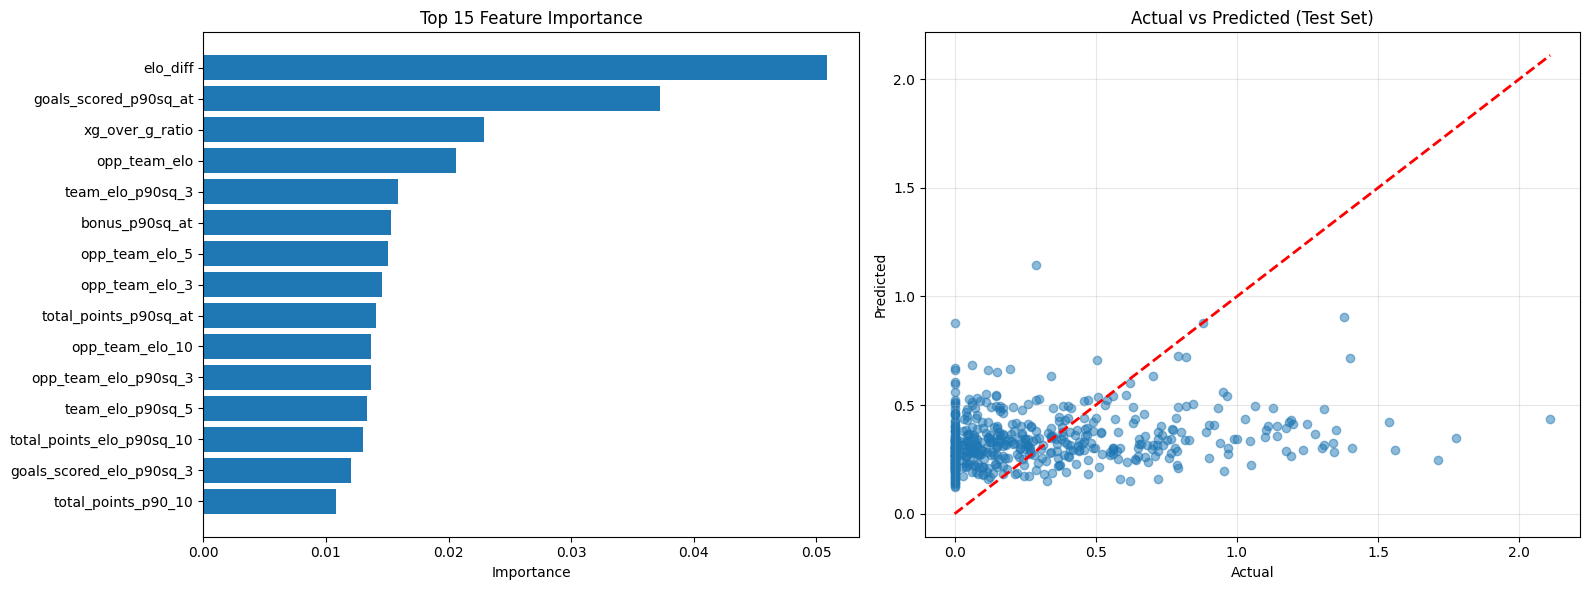

target=expected_goals_per90, MID_xG_predictor
Cleaned df size: 11627/18039

Training Set Performance:
R² Score: 0.3912
RMSE: 0.1730
MAE: 0.1173

Test Set Performance:
R² Score: 0.0805
RMSE: 0.2150
MAE: 0.1391

Top 20 Feature Importances:
                feature  importance
  goals_scored_p90sq_at    0.147822
           opp_team_elo    0.041201
         bonus_p90sq_at    0.020702
        opp_team_elo_10    0.019161
               elo_diff    0.017683
           bps_p90sq_at    0.017021
    total_points_elo_10    0.016105
           bps_p90sq_10    0.012583
         opp_team_elo_3    0.012394
      team_elo_p90sq_at    0.012006
             bps_elo_10    0.011418
         opp_team_elo_5    0.011287
    goals_scored_elo_10    0.011185
  total_points_p90sq_at    0.010958
  goals_conceded_elo_10    0.010504
            bps_p90sq_3    0.010433
goals_conceded_p90sq_at    0.010144
  opp_team_elo_p90sq_at    0.010042
              bps_p90_3    0.009173
     total_points_elo_5    0.008898


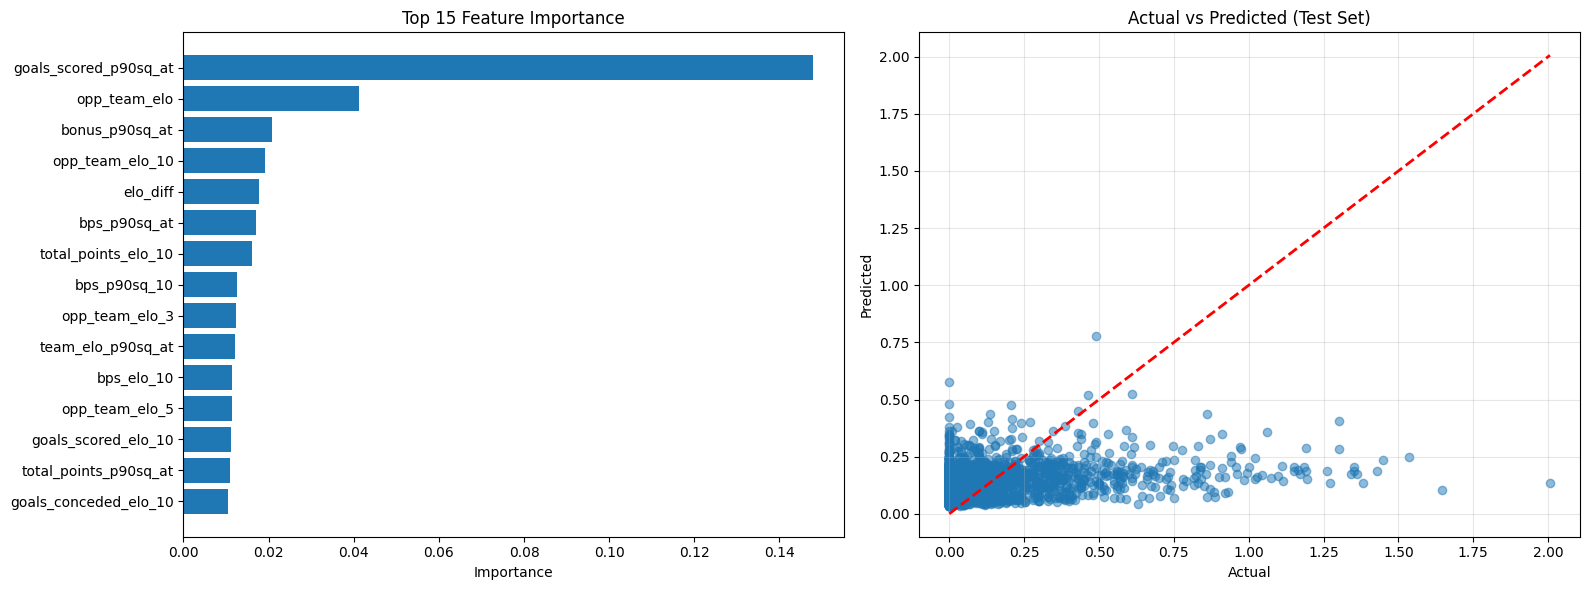

target=expected_goals_per90, DEF_xG_predictor
Cleaned df size: 9945/16134

Training Set Performance:
R² Score: 0.2725
RMSE: 0.0904
MAE: 0.0550

Test Set Performance:
R² Score: -0.0182
RMSE: 0.1067
MAE: 0.0586

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.045131
               opp_team_elo    0.036216
    goals_conceded_p90sq_at    0.021434
        goals_scored_elo_10    0.020883
          team_elo_p90sq_at    0.019674
             opp_team_elo_5    0.019091
               bps_p90sq_at    0.018889
                   elo_diff    0.018161
     opp_team_elo_elo_p90_5    0.017150
      opp_team_elo_p90sq_10    0.015425
     opp_team_elo_elo_p90_3    0.015324
            opp_team_elo_10    0.014826
         total_points_elo_5    0.014553
      total_points_p90sq_at    0.014542
              minutes_elo_5    0.014041
             opp_team_elo_3    0.013912
       minutes_elo_p90sq_10    0.013425
goals_conceded_elo_p90sq_10    0.012808
  

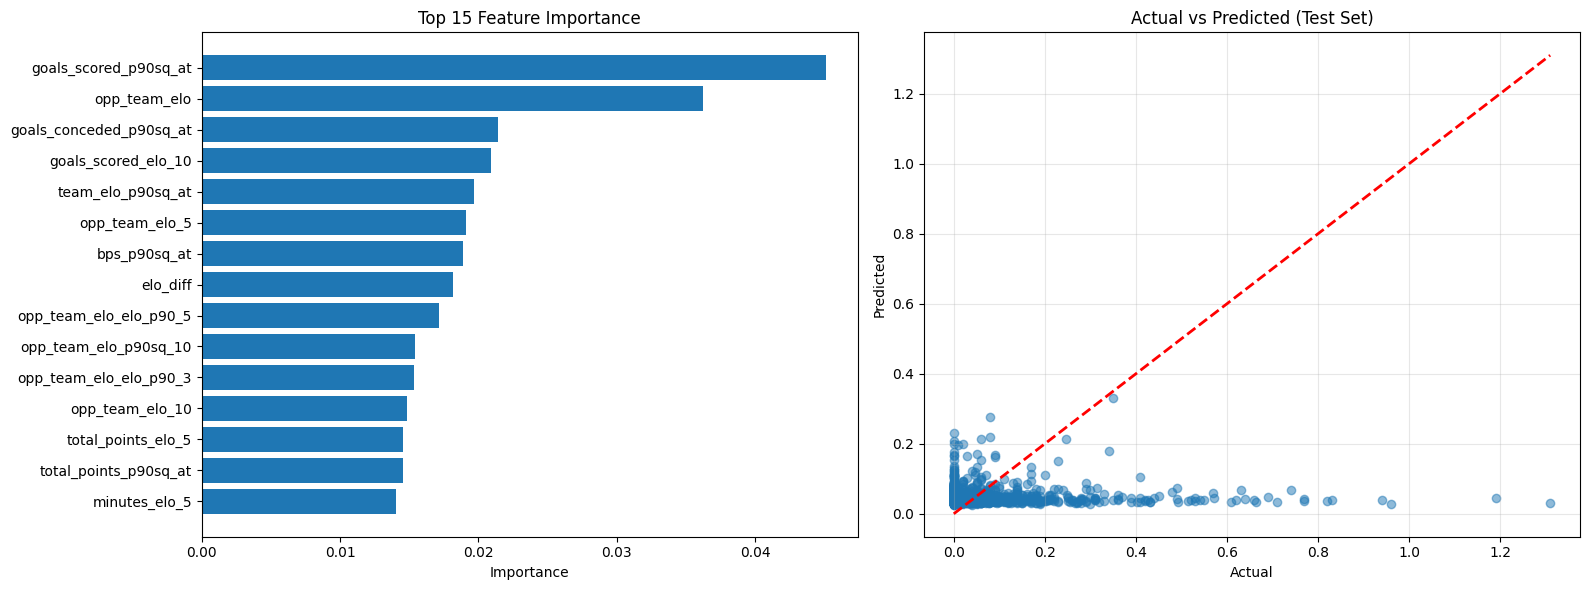

In [12]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)&(df['total_points']<12)

if __name__ == "__main__":
    
    print("target=expected_goals_per90, FWD_xG_predictor")
    FWD_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xG_predictor.fit()
    FWD_xG_predictor.plot_results()

    print("target=expected_goals_per90, MID_xG_predictor")
    MID_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xG_predictor.fit()
    MID_xG_predictor.plot_results()
    
    print("target=expected_goals_per90, DEF_xG_predictor")
    DEF_xG_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xG_predictor.fit()
    DEF_xG_predictor.plot_results()

target=expected_assists_per90, FWD_xA_predictor
Cleaned df size: 2682/4492

Training Set Performance:
R² Score: 0.5373
RMSE: 0.0807
MAE: 0.0542

Test Set Performance:
R² Score: 0.0278
RMSE: 0.1242
MAE: 0.0752

Top 20 Feature Importances:
                 feature  importance
            opp_team_elo    0.044857
                elo_diff    0.032779
          opp_team_elo_3    0.019340
    goals_conceded_elo_3    0.018723
           minutes_elo_3    0.018087
         xg_over_g_ratio    0.017728
    total_points_p90sq_3    0.017571
       minutes_elo_p90_5    0.016109
          opp_team_elo_5    0.016090
       minutes_elo_p90_3    0.014121
          minutes_elo_10    0.012634
             bonus_elo_3    0.011984
       team_elo_p90sq_at    0.011895
    goals_conceded_elo_5    0.011856
 opp_team_elo_elo_p90_10    0.011856
total_points_elo_p90sq_3    0.011815
    opp_team_elo_p90sq_5    0.011682
            bonus_elo_10    0.011294
      team_elo_elo_p90_3    0.011274
  total_points_elo_p90

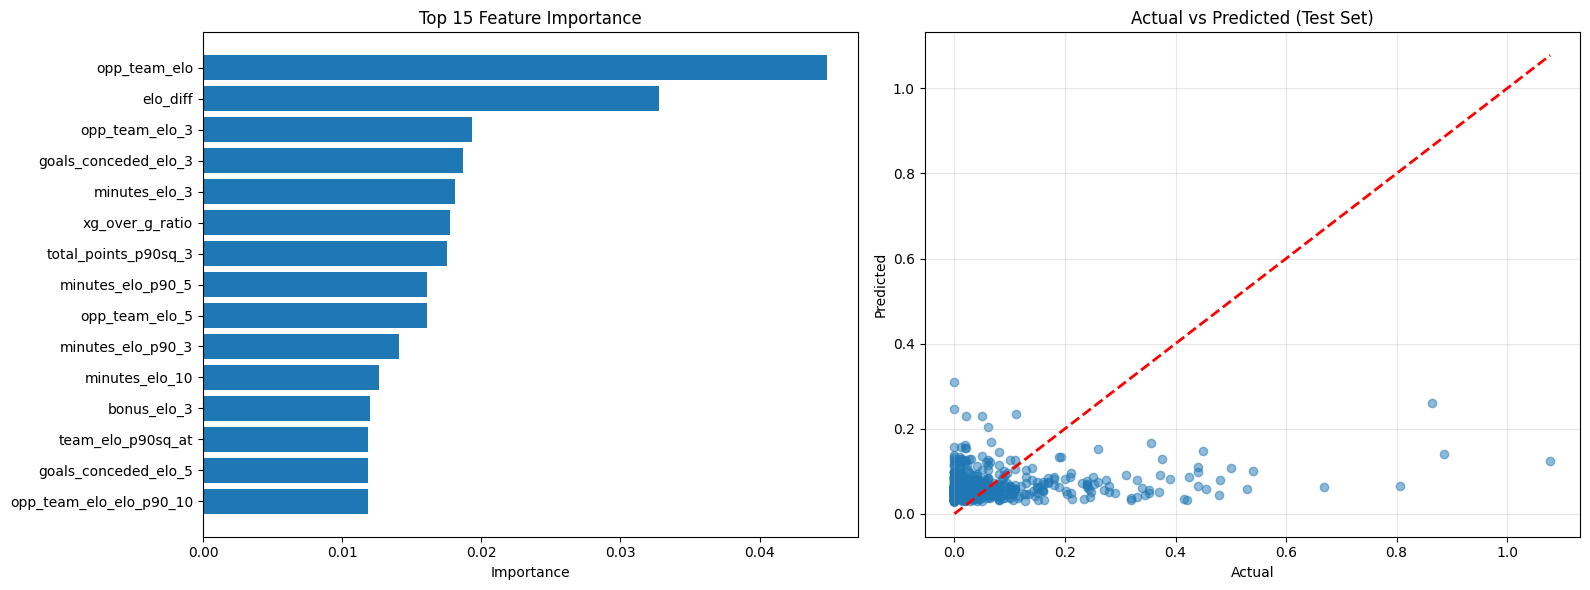

target=expected_assists_per90, MID_xA_predictor
Cleaned df size: 12039/18655

Training Set Performance:
R² Score: 0.4113
RMSE: 0.1259
MAE: 0.0894

Test Set Performance:
R² Score: 0.0731
RMSE: 0.1529
MAE: 0.1035

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.103354
         bonus_p90sq_at    0.072542
    total_points_elo_10    0.036415
           opp_team_elo    0.021723
             bps_elo_10    0.021122
  goals_scored_p90sq_at    0.018424
      team_elo_p90sq_at    0.014954
        opp_team_elo_10    0.013305
         opp_team_elo_5    0.013021
           bps_p90sq_at    0.012942
  clean_sheets_p90sq_at    0.011506
           bps_p90sq_10    0.010173
        total_points_10    0.009715
         opp_team_elo_3    0.009658
         bps_elo_p90_10    0.009351
             bps_p90_10    0.009097
  total_points_p90sq_at    0.009060
goals_conceded_p90sq_at    0.008802
                 bps_10    0.008779
   opp_team_elo_p90sq_5    0.008242


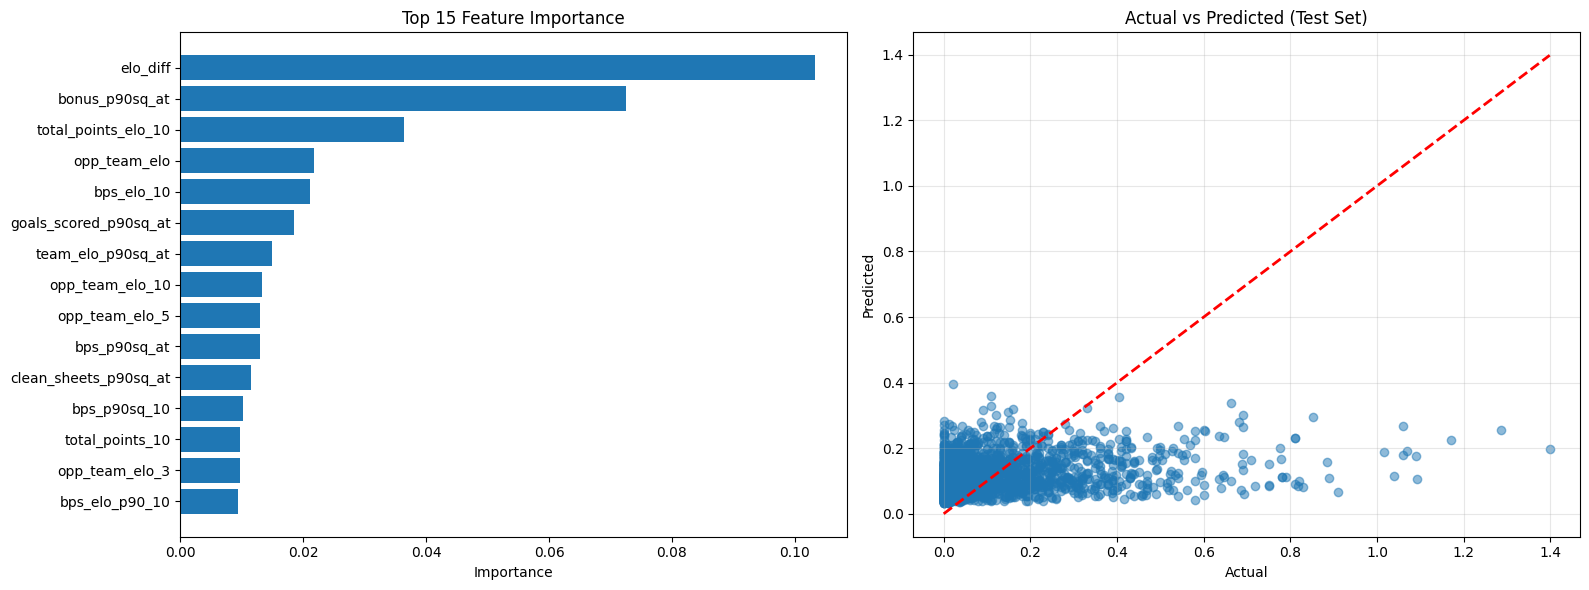

target=expected_assists_per90, DEF_xA_predictor
Cleaned df size: 10137/16450

Training Set Performance:
R² Score: 0.3872
RMSE: 0.0815
MAE: 0.0499

Test Set Performance:
R² Score: 0.0711
RMSE: 0.0997
MAE: 0.0582

Top 20 Feature Importances:
                feature  importance
         bonus_p90sq_at    0.113706
               elo_diff    0.040208
           opp_team_elo    0.034003
goals_conceded_p90sq_at    0.027703
                  bps_3    0.019166
  goals_scored_p90sq_at    0.017273
            bps_p90sq_5    0.017262
         opp_team_elo_3    0.017092
  clean_sheets_p90sq_at    0.013830
           bps_p90sq_at    0.013747
        opp_team_elo_10    0.013555
          bps_elo_p90_5    0.013235
                 bps_10    0.012335
      team_elo_p90sq_at    0.012244
 opp_team_elo_elo_p90_3    0.012074
   goals_conceded_elo_3    0.011951
total_points_elo_p90_10    0.011820
    total_points_p90_10    0.011649
            bps_p90sq_3    0.011202
  opp_team_elo_p90sq_at    0.010959


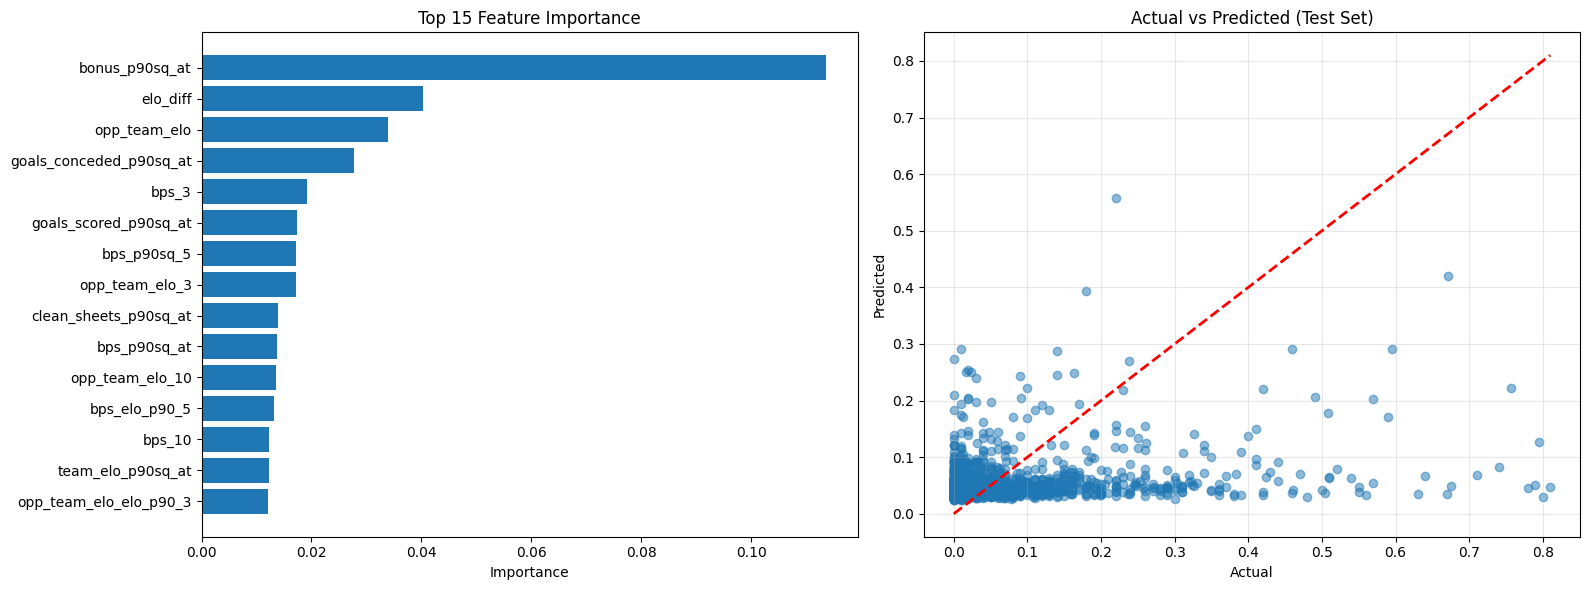

In [13]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_assists_per90, FWD_xA_predictor")
    FWD_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xA_predictor.fit()
    FWD_xA_predictor.plot_results()

    print("target=expected_assists_per90, MID_xA_predictor")
    MID_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xA_predictor.fit()
    MID_xA_predictor.plot_results()
    
    print("target=expected_assists_per90, DEF_xA_predictor")
    DEF_xA_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_assists_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xA_predictor.fit()
    DEF_xA_predictor.plot_results()

target=expected_goals_conceded_per90, FWD_xGC_predictor
Cleaned df size: 2682/4492

Training Set Performance:
R² Score: 0.6764
RMSE: 0.5250
MAE: 0.4251

Test Set Performance:
R² Score: 0.1272
RMSE: 0.9084
MAE: 0.7031

Top 20 Feature Importances:
                    feature  importance
                   elo_diff    0.149795
            xg_over_g_ratio    0.042527
               opp_team_elo    0.042379
      clean_sheets_p90sq_at    0.022753
            opp_team_elo_10    0.017412
    goals_conceded_p90sq_at    0.013837
             team_elo_elo_5    0.013796
             opp_team_elo_3    0.013192
             opp_team_elo_5    0.011384
      goals_scored_p90sq_at    0.009633
          team_elo_p90sq_at    0.009589
               bps_p90sq_at    0.009502
    goals_conceded_p90sq_10    0.009490
         opp_team_elo_elo_5    0.009383
             bonus_p90sq_at    0.008833
         minutes_elo_p90_10    0.008588
      total_points_p90sq_at    0.008289
        total_points_elo_10    0.0

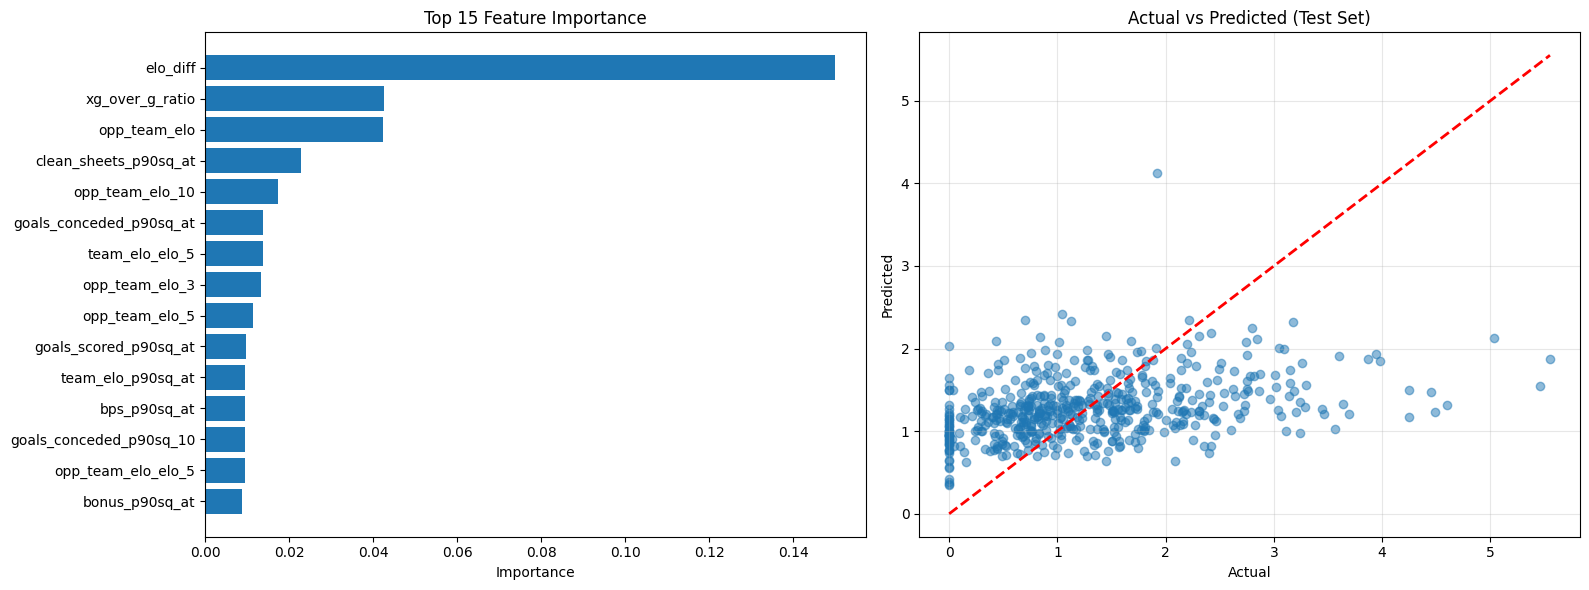

target=expected_goals_conceded_per90, MID_xGC_predictor
Cleaned df size: 12039/18655

Training Set Performance:
R² Score: 0.5515
RMSE: 0.6274
MAE: 0.4996

Test Set Performance:
R² Score: 0.3381
RMSE: 0.7795
MAE: 0.6102

Top 20 Feature Importances:
              feature  importance
             elo_diff    0.242285
         opp_team_elo    0.076308
       opp_team_elo_5    0.033171
      opp_team_elo_10    0.032273
       opp_team_elo_3    0.027994
             team_elo    0.027836
          team_elo_10    0.024560
           team_elo_3    0.021654
           team_elo_5    0.020894
       team_elo_elo_3    0.018400
       team_elo_elo_5    0.016163
   opp_team_elo_elo_5    0.016115
   opp_team_elo_elo_3    0.015894
clean_sheets_p90sq_at    0.014803
    minutes_elo_p90_3    0.011892
      team_elo_elo_10    0.010514
  opp_team_elo_elo_10    0.010348
  minutes_elo_p90sq_3    0.010221
  minutes_elo_p90sq_5    0.009113
 minutes_elo_p90sq_10    0.008897


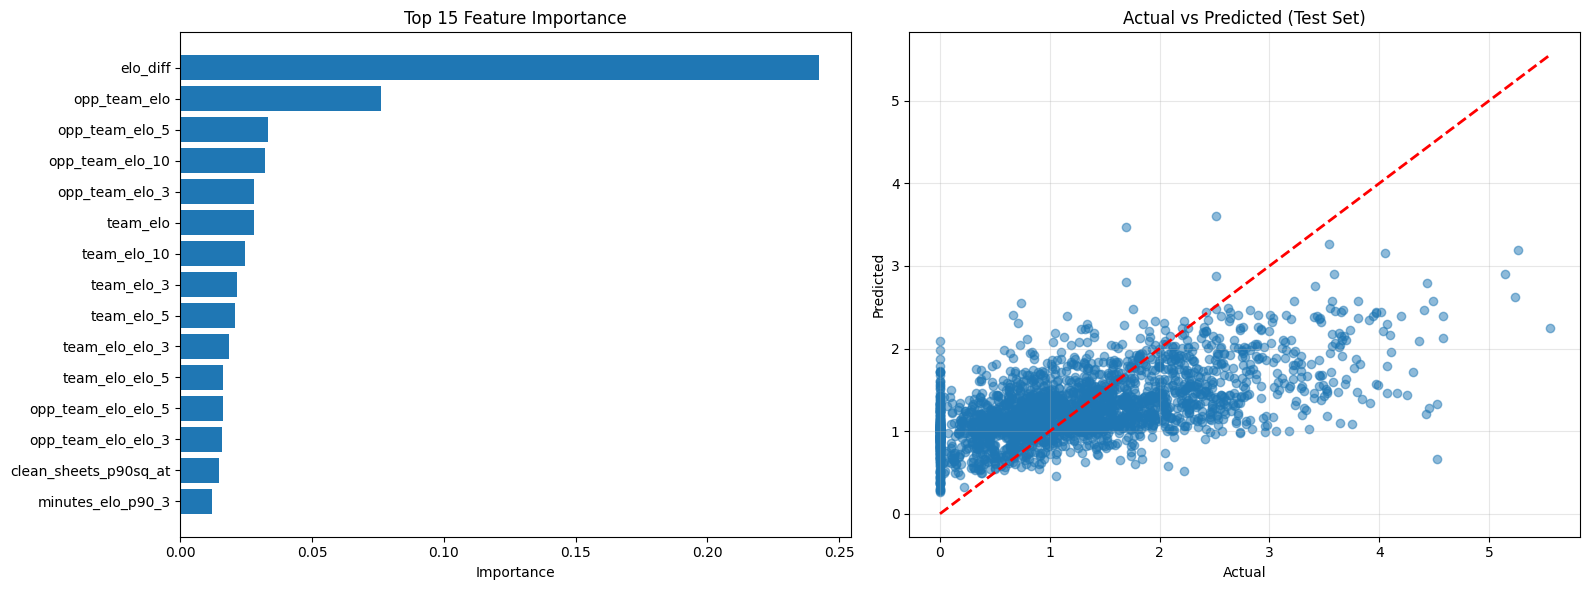

target=expected_goals_conceded_per90, DEF_xGC_predictor
Cleaned df size: 10137/16450

Training Set Performance:
R² Score: 0.5797
RMSE: 0.6060
MAE: 0.4802

Test Set Performance:
R² Score: 0.3178
RMSE: 0.7967
MAE: 0.6107

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.212115
           opp_team_elo    0.080618
    opp_team_elo_elo_10    0.030853
        opp_team_elo_10    0.030545
         opp_team_elo_5    0.027566
            team_elo_10    0.023224
         opp_team_elo_3    0.020533
               team_elo    0.019921
             team_elo_5    0.019805
         team_elo_elo_3    0.015986
         team_elo_elo_5    0.015953
             team_elo_3    0.015692
  clean_sheets_p90sq_at    0.015647
     opp_team_elo_elo_3    0.014417
goals_conceded_p90sq_at    0.013925
     opp_team_elo_elo_5    0.013070
        team_elo_elo_10    0.012951
    minutes_elo_p90sq_3    0.011737
      minutes_elo_p90_3    0.010729
      team_elo_p90sq_at    0.009

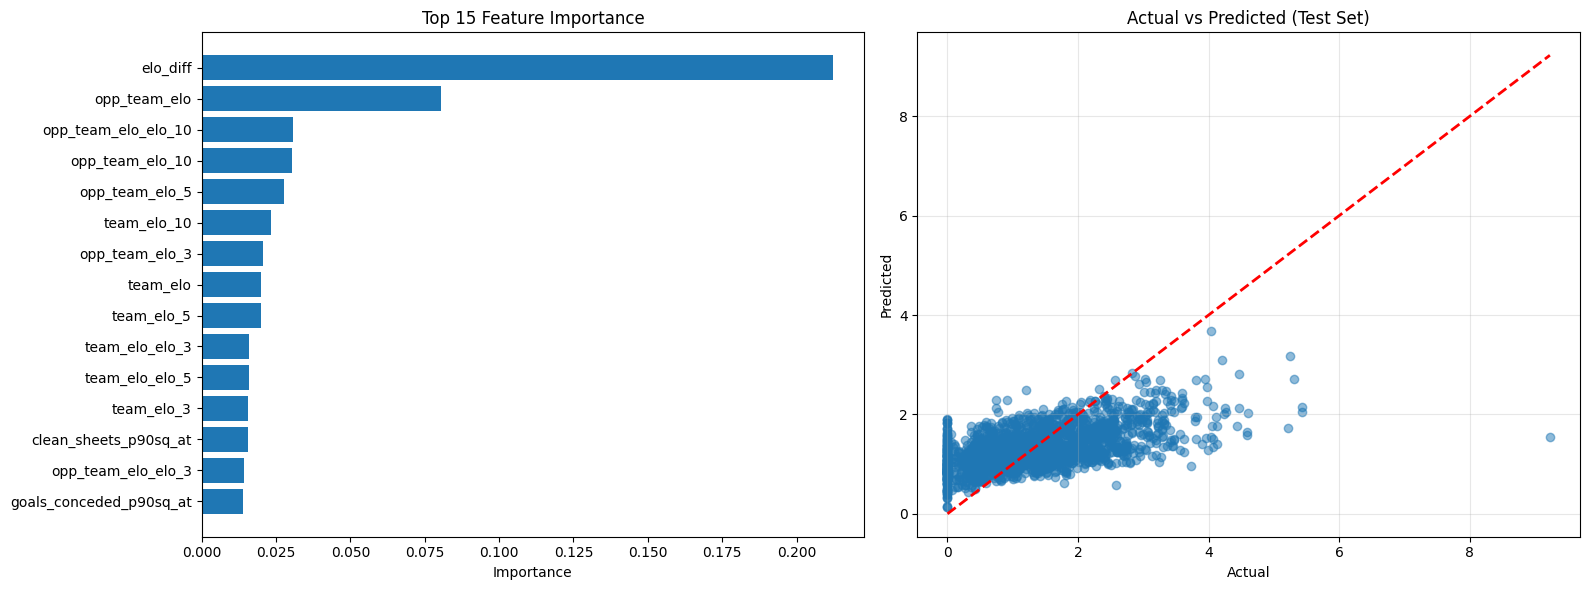

target=expected_goals_conceded_per90, GK_xGC_predictor
Cleaned df size: 2487/4021

Training Set Performance:
R² Score: 0.6949
RMSE: 0.5146
MAE: 0.4151

Test Set Performance:
R² Score: 0.1364
RMSE: 0.8322
MAE: 0.6516

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.158717
           opp_team_elo    0.041385
  opp_team_elo_p90sq_at    0.028123
         saves_p90sq_at    0.028072
goals_conceded_p90sq_at    0.023272
      team_elo_p90sq_at    0.019983
  opp_team_elo_p90sq_10    0.016772
     saves_elo_p90sq_10    0.016136
        opp_team_elo_10    0.014529
  total_points_p90sq_at    0.014029
           bps_p90sq_at    0.013676
      saves_elo_p90sq_3    0.012398
         saves_p90sq_10    0.012067
         bonus_p90sq_at    0.011757
         opp_team_elo_5    0.011632
           bps_p90sq_10    0.011235
  clean_sheets_p90sq_at    0.011127
   opp_team_elo_p90sq_5    0.010897
   opp_team_elo_p90sq_3    0.010573
         opp_team_elo_3    0.009975

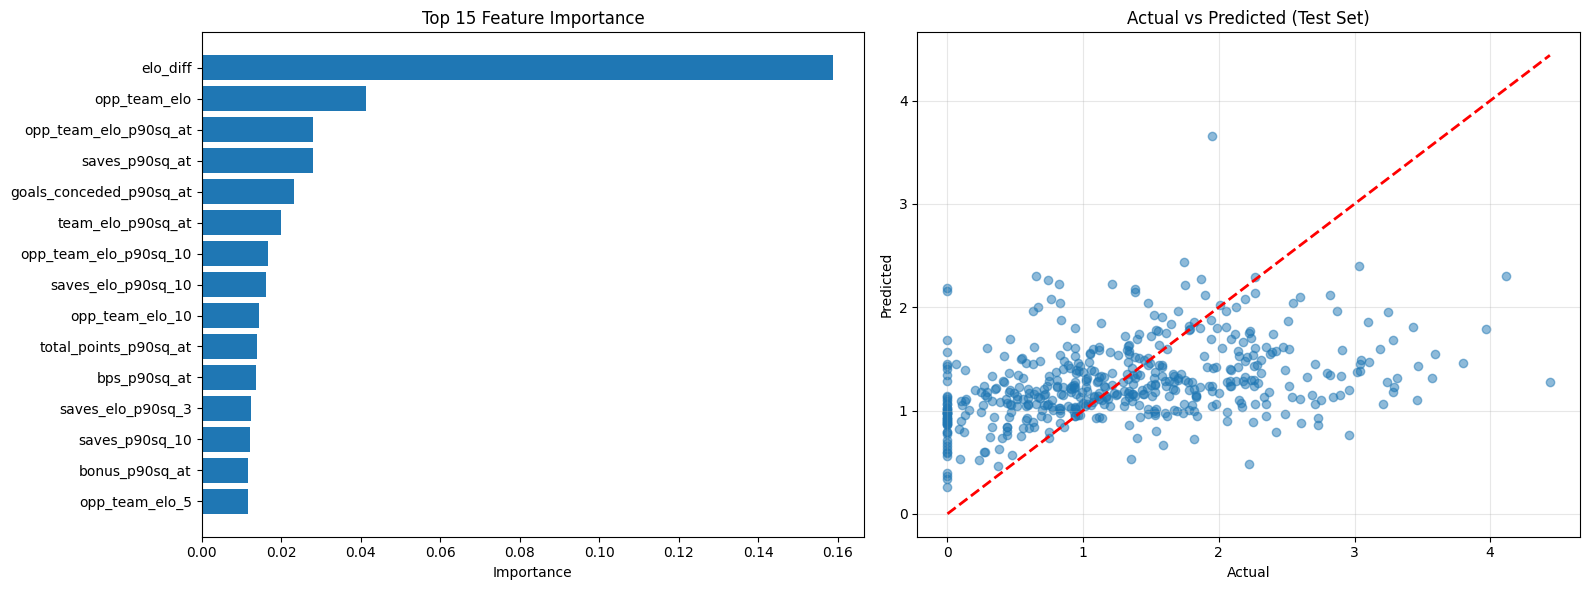

In [14]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=expected_goals_conceded_per90, FWD_xGC_predictor")
    FWD_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_xGC_predictor.fit()
    FWD_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, MID_xGC_predictor")
    MID_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_xGC_predictor.fit()
    MID_xGC_predictor.plot_results()
    
    print("target=expected_goals_conceded_per90, DEF_xGC_predictor")
    DEF_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_xGC_predictor.fit()
    DEF_xGC_predictor.plot_results()

    print("target=expected_goals_conceded_per90, GK_xGC_predictor")
    GK_xGC_predictor = FPLPredictor(
        data=df[filtered],
        target='expected_goals_conceded_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_xGC_predictor.fit()
    GK_xGC_predictor.plot_results()

target=bps_per90, FWD_bps_predictor
Cleaned df size: 3986/4492

Training Set Performance:
R² Score: 0.4981
RMSE: 13.1591
MAE: 10.6641

Test Set Performance:
R² Score: -0.0234
RMSE: 18.7139
MAE: 14.7624

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.084554
             opp_team_elo    0.027627
       opp_team_elo_elo_5    0.018007
                bps_elo_5    0.016569
           bonus_p90sq_at    0.015092
           opp_team_elo_3    0.014611
  goals_conceded_p90sq_at    0.013884
        minutes_elo_p90_3    0.012635
          opp_team_elo_10    0.012070
clean_sheets_elo_p90sq_10    0.011971
     goals_conceded_elo_5    0.011801
           opp_team_elo_5    0.011789
    opp_team_elo_p90sq_at    0.011460
               bps_elo_10    0.010692
    opp_team_elo_p90sq_10    0.010275
     goals_conceded_elo_3    0.009824
       minutes_elo_p90_10    0.009721
    total_points_p90sq_at    0.009580
    clean_sheets_p90sq_at    0.009256
    goals

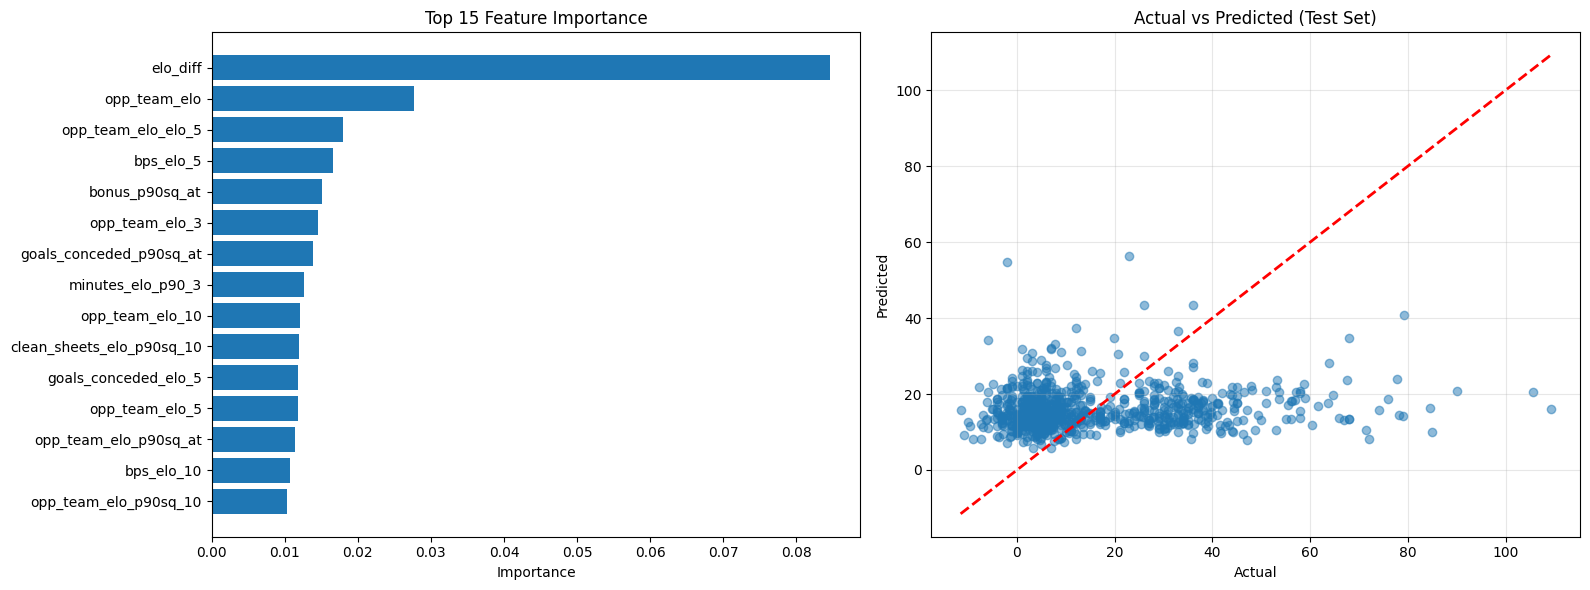

target=bps_per90, MID_bps_predictor
Cleaned df size: 18053/18655

Training Set Performance:
R² Score: 0.3266
RMSE: 9.4066
MAE: 7.1311

Test Set Performance:
R² Score: 0.0476
RMSE: 11.1279
MAE: 8.1862

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.134739
             bps_elo_10    0.027074
                 bps_10    0.024778
         bonus_p90sq_at    0.023745
           opp_team_elo    0.021648
        opp_team_elo_10    0.018342
                  bps_5    0.017671
         opp_team_elo_5    0.015374
         opp_team_elo_3    0.015345
  goals_scored_p90sq_at    0.012799
           bps_p90sq_at    0.010329
  clean_sheets_p90sq_at    0.010010
goals_conceded_p90sq_at    0.009906
      team_elo_p90sq_at    0.009409
  opp_team_elo_p90sq_at    0.009226
             bps_p90_10    0.009080
    total_points_elo_10    0.009009
         minutes_elo_10    0.008927
              bps_elo_5    0.008878
              bps_p90_3    0.008705


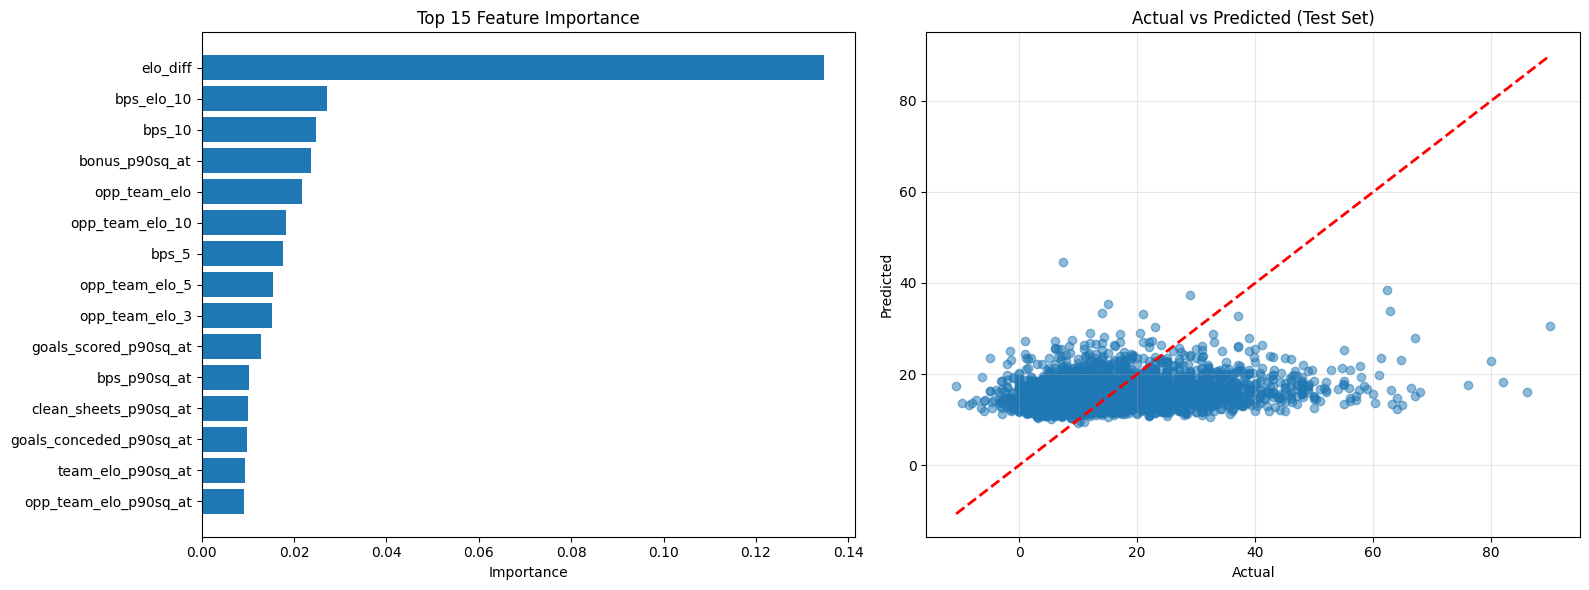

target=bps_per90, DEF_bps_predictor
Cleaned df size: 15464/16450

Training Set Performance:
R² Score: 0.4203
RMSE: 7.5150
MAE: 6.0136

Test Set Performance:
R² Score: 0.1441
RMSE: 8.9971
MAE: 7.0562

Top 20 Feature Importances:
                feature  importance
               elo_diff    0.226159
           opp_team_elo    0.029785
        opp_team_elo_10    0.026666
         opp_team_elo_5    0.023259
         opp_team_elo_3    0.017675
         bonus_p90sq_at    0.017562
            team_elo_10    0.014140
               team_elo    0.012698
             bps_p90_10    0.012199
            bps_p90sq_5    0.011897
goals_conceded_p90sq_at    0.011124
                 bps_10    0.010385
            bps_p90sq_3    0.009708
           bps_p90sq_at    0.009358
        bps_elo_p90sq_3    0.009140
  clean_sheets_p90sq_at    0.008992
             team_elo_3    0.008512
              bps_p90_5    0.008462
  goals_scored_p90sq_at    0.008358
             team_elo_5    0.008350


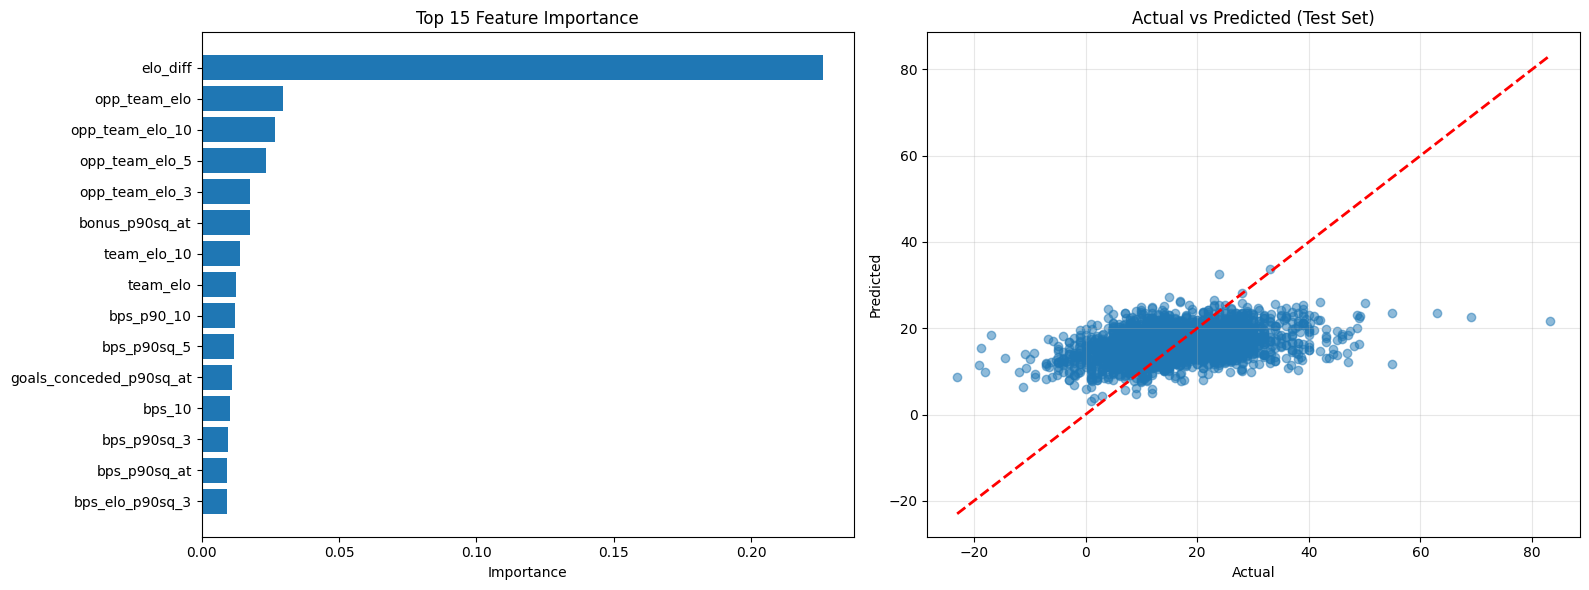

target=bps_per90, GK_bps_predictor
Cleaned df size: 3785/4021

Training Set Performance:
R² Score: 0.5544
RMSE: 5.9340
MAE: 4.8280

Test Set Performance:
R² Score: 0.0199
RMSE: 8.5491
MAE: 6.7866

Top 20 Feature Importances:
                    feature  importance
               bps_p90sq_10    0.034491
            opp_team_elo_10    0.034279
               opp_team_elo    0.031105
                 bps_p90_10    0.024589
      opp_team_elo_p90sq_at    0.021786
               bps_p90sq_at    0.021272
           bps_elo_p90sq_10    0.018560
      total_points_p90sq_10    0.018450
             opp_team_elo_3    0.016709
             saves_p90sq_10    0.016350
      opp_team_elo_p90sq_10    0.016151
                   elo_diff    0.015959
goals_conceded_elo_p90sq_10    0.015814
             opp_team_elo_5    0.015789
                bps_p90sq_5    0.015345
             saves_p90sq_at    0.015072
          team_elo_p90sq_at    0.014925
    goals_conceded_p90sq_at    0.014766
               

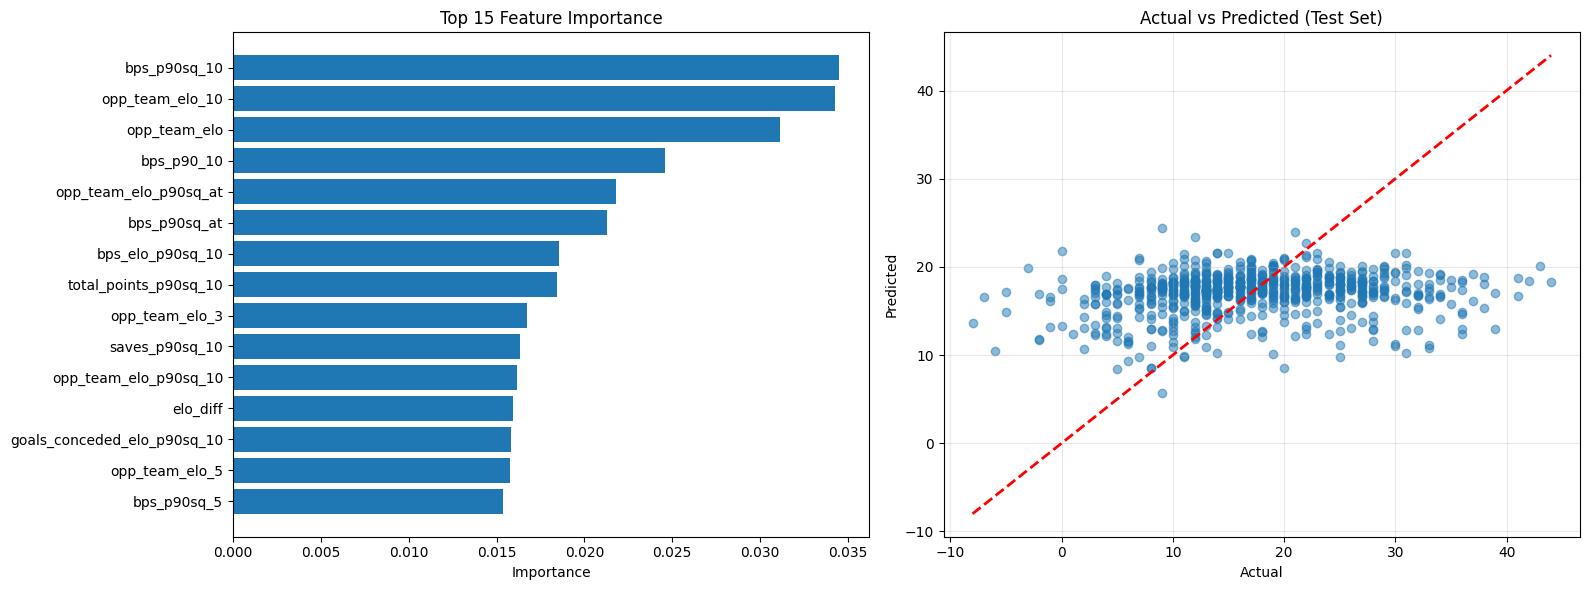

In [15]:
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>100)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=bps_per90, FWD_bps_predictor")
    FWD_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90', # try: 'bonus_per90'
        positions={'FWD'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_bps_predictor.fit()
    FWD_bps_predictor.plot_results()

    print("target=bps_per90, MID_bps_predictor")
    MID_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'MID'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_bps_predictor.fit()
    MID_bps_predictor.plot_results()
    
    print("target=bps_per90, DEF_bps_predictor")
    DEF_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'DEF'},
        columns_to_drop = cbi_defcon_cols,
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_bps_predictor.fit()
    DEF_bps_predictor.plot_results()

    print("target=bps_per90, GK_bps_predictor")
    GK_bps_predictor = FPLPredictor(
        data=df[filtered],
        target='bps_per90',
        positions={'GK'},
        columns_to_drop = cbi_defcon_cols,
        max_nan_pct=10)
    GK_bps_predictor.fit()
    GK_bps_predictor.plot_results()

target=saves_per90, GK_saves_predictor
Cleaned df size: 3785/4040

Training Set Performance:
R² Score: 0.5850
RMSE: 1.2787
MAE: 1.0292

Test Set Performance:
R² Score: 0.0608
RMSE: 1.8119
MAE: 1.4576

Top 20 Feature Importances:
                  feature  importance
                 elo_diff    0.149120
             opp_team_elo    0.021021
           saves_p90sq_at    0.019930
           opp_team_elo_5    0.017417
          opp_team_elo_10    0.017091
  goals_conceded_p90sq_at    0.016346
    opp_team_elo_p90sq_at    0.016170
           opp_team_elo_3    0.014771
           saves_p90sq_10    0.014657
             bps_p90sq_at    0.014174
    opp_team_elo_p90sq_10    0.013915
        team_elo_p90sq_at    0.013632
       saves_elo_p90sq_10    0.013394
        saves_elo_p90sq_5    0.012084
    total_points_p90sq_at    0.012004
            saves_p90sq_5    0.011765
     opp_team_elo_p90sq_3    0.011523
           bonus_p90sq_at    0.011120
    total_points_p90sq_10    0.010383
total_point

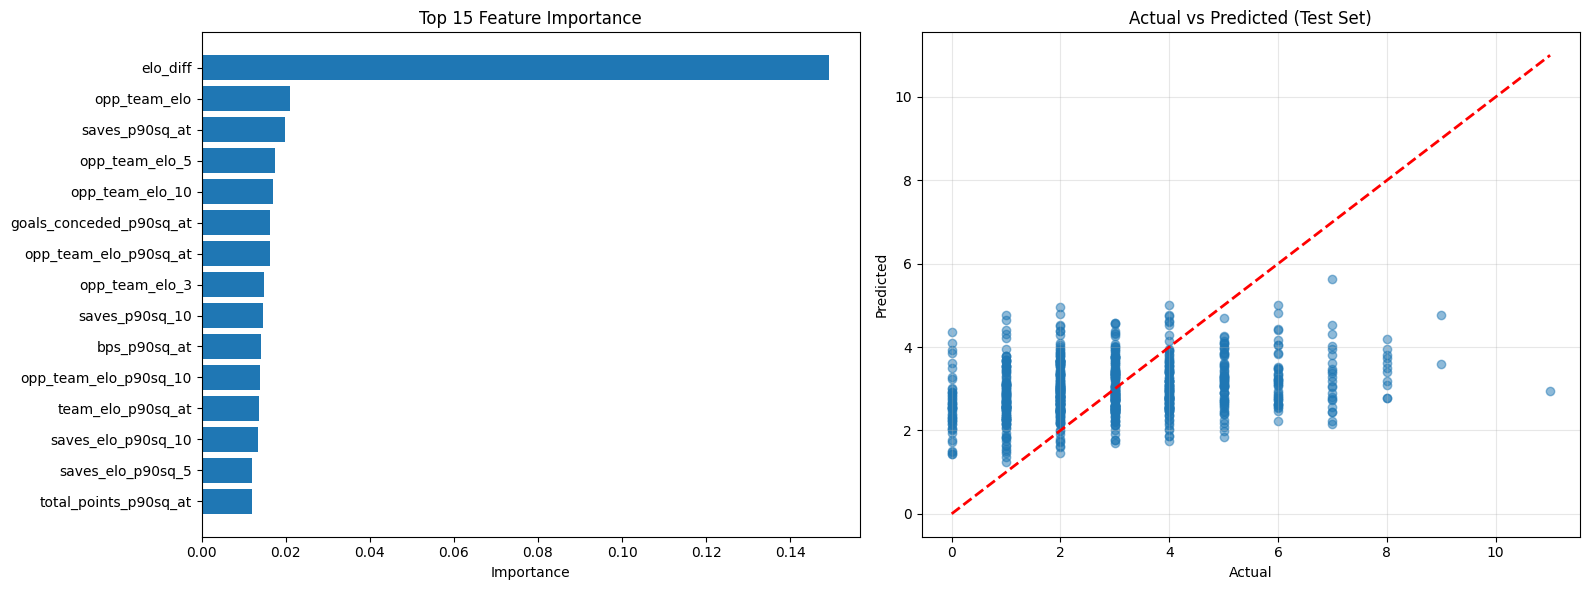

In [16]:
#shots saved
filtered = (df['minutes']>45)&(df['player_season_minutes_total']>0)#&(df['total_points']<15)

if __name__ == "__main__":
    
    print("target=saves_per90, GK_saves_predictor")
    GK_saves_predictor = FPLPredictor(
        data=df[filtered],
        target='saves_per90',
        positions={'GK'},
        max_nan_pct=10)
    GK_saves_predictor.fit()
    GK_saves_predictor.plot_results()

target=defensive_contribution_per90, FWD_defcon_predictor
Cleaned df size: 472/4966

Training Set Performance:
R² Score: 0.8013
RMSE: 1.2309
MAE: 0.9687

Test Set Performance:
R² Score: -0.0130
RMSE: 2.9693
MAE: 2.2986

Top 20 Feature Importances:
                   feature  importance
   goals_conceded_p90sq_at    0.034000
     goals_conceded_p90_10    0.029489
            opp_team_elo_5    0.027736
     goals_scored_p90sq_at    0.025469
      total_points_p90sq_3    0.022985
     opp_team_elo_p90sq_at    0.021196
                minutes_10    0.020297
              bps_p90sq_at    0.017989
          team_elo_p90sq_5    0.017892
      opp_team_elo_p90sq_5    0.017426
              opp_team_elo    0.017000
           opp_team_elo_10    0.016600
                  elo_diff    0.015270
            bonus_p90sq_at    0.014017
            opp_team_elo_3    0.013514
 goals_conceded_elo_p90_10    0.013189
               bps_p90sq_5    0.013161
goals_conceded_elo_p90sq_5    0.013062
     clean_

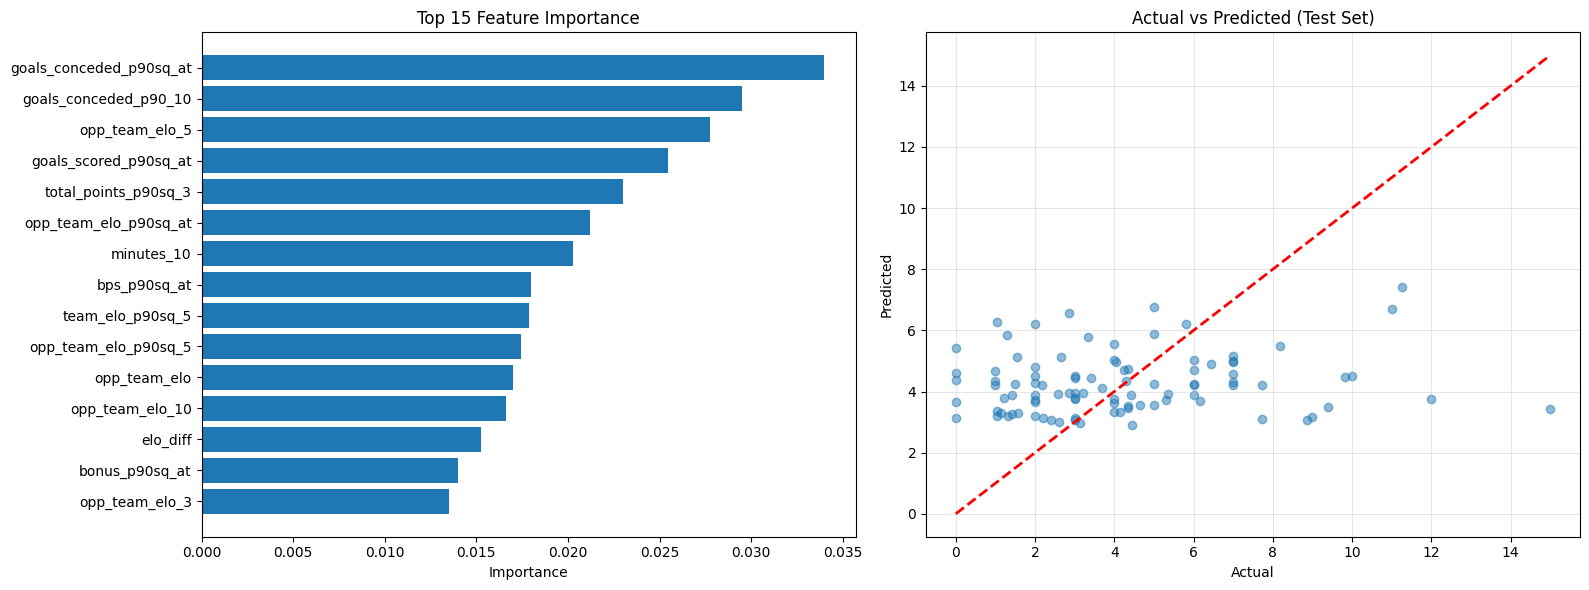

target=defensive_contribution_per90, MID_defcon_predictor
Cleaned df size: 2260/20509

Training Set Performance:
R² Score: 0.6876
RMSE: 2.3621
MAE: 1.8931

Test Set Performance:
R² Score: 0.1587
RMSE: 3.8242
MAE: 3.0891

Top 20 Feature Importances:
                    feature  importance
      goals_scored_p90sq_at    0.112127
    goals_conceded_p90sq_at    0.039701
          team_elo_p90sq_at    0.024531
             bonus_p90sq_at    0.021593
      total_points_p90sq_at    0.016296
       opp_team_elo_p90sq_3    0.015687
               bps_p90sq_at    0.014909
               opp_team_elo    0.014573
      clean_sheets_p90sq_at    0.013967
             opp_team_elo_3    0.013670
                      bps_3    0.013028
             opp_team_elo_5    0.012923
              minutes_elo_5    0.012670
      goals_conceded_p90_10    0.011853
goals_conceded_elo_p90sq_10    0.011767
                   team_elo    0.011276
      opp_team_elo_p90sq_at    0.010941
                   elo_diff    

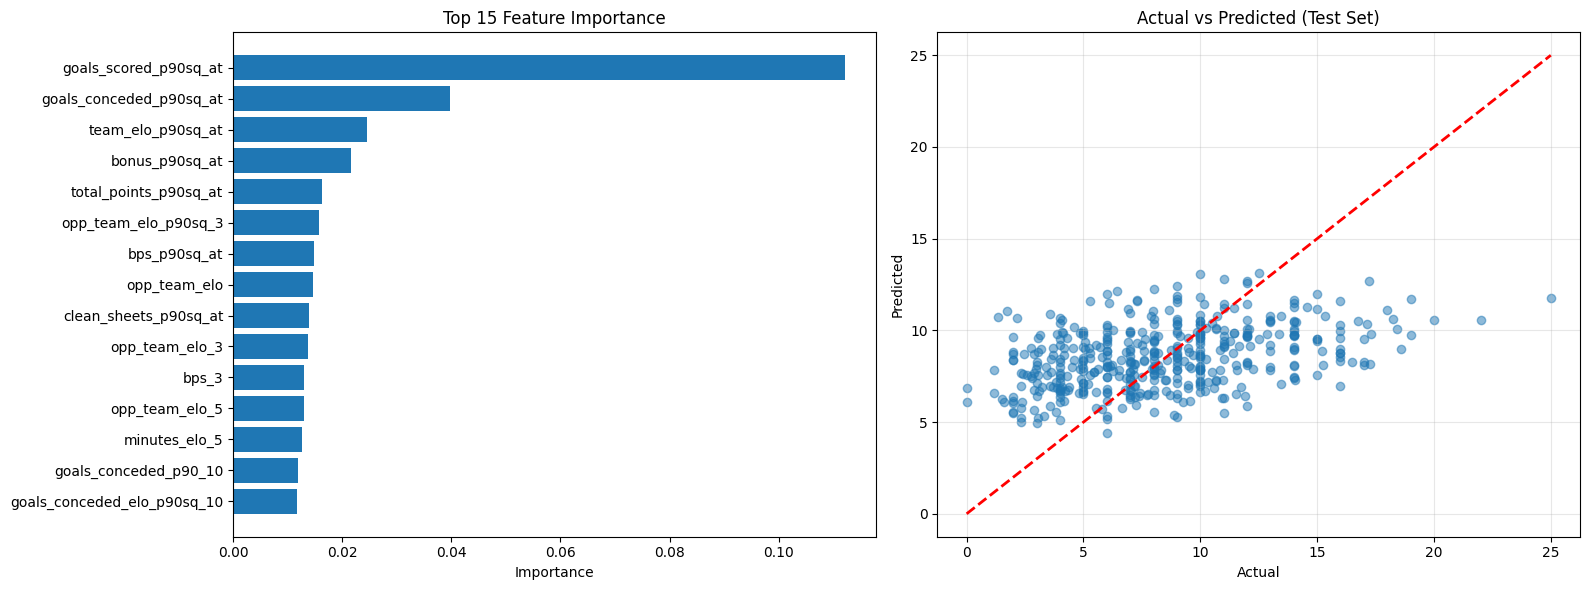

target=defensive_contribution_per90, DEF_defcon_predictor
Cleaned df size: 1892/17379

Training Set Performance:
R² Score: 0.6843
RMSE: 2.1953
MAE: 1.7924

Test Set Performance:
R² Score: 0.0765
RMSE: 3.7947
MAE: 2.9474

Top 20 Feature Importances:
                feature  importance
       team_elo_p90sq_5    0.020331
        bps_elo_p90sq_3    0.020053
goals_conceded_p90sq_at    0.019942
               elo_diff    0.019626
  opp_team_elo_p90sq_at    0.019438
         bonus_p90sq_at    0.018850
           opp_team_elo    0.017940
opp_team_elo_elo_p90_10    0.016939
  total_points_p90sq_at    0.015784
        opp_team_elo_10    0.015540
   opp_team_elo_p90sq_5    0.015029
            bps_p90sq_3    0.014829
   opp_team_elo_p90sq_3    0.014311
  goals_conceded_elo_10    0.014277
      team_elo_p90sq_at    0.013592
  goals_scored_p90sq_at    0.013564
   total_points_p90sq_5    0.013476
  opp_team_elo_p90sq_10    0.013173
         opp_team_elo_5    0.012942
           bps_p90sq_at    0.01

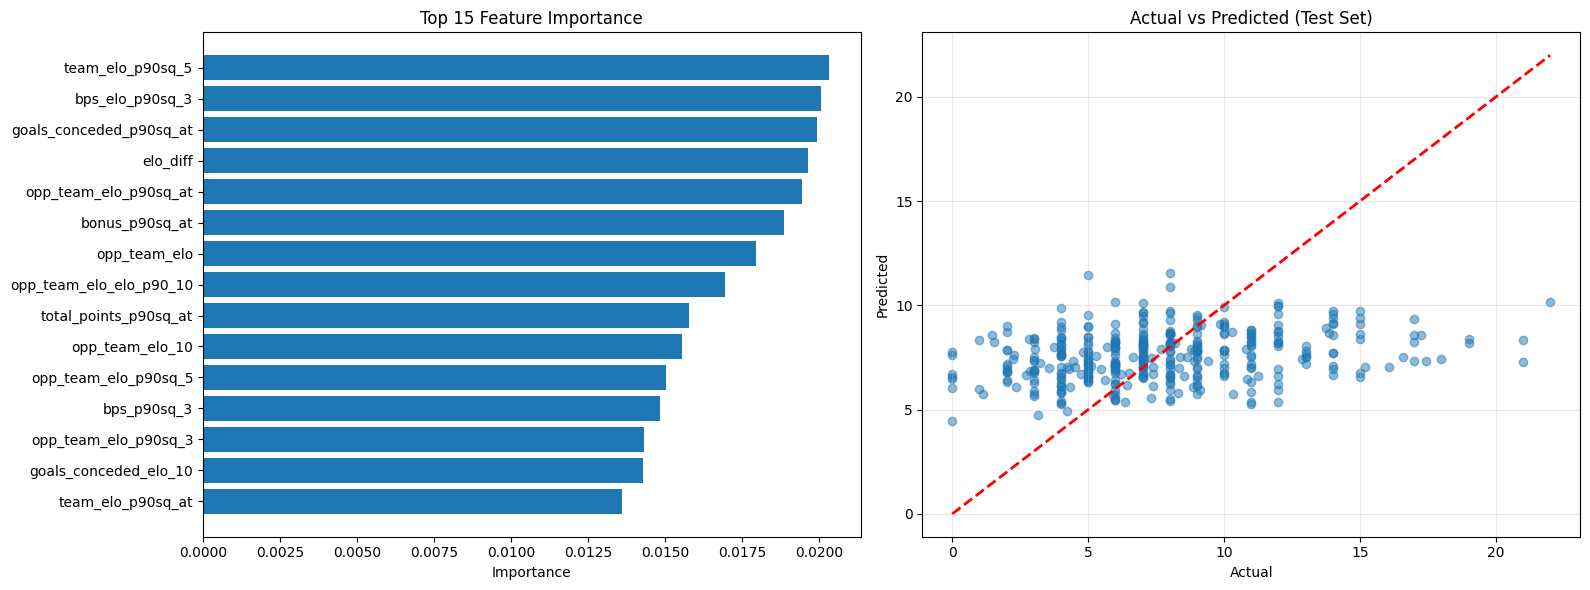

In [17]:
# >10 defcon (CBIT) for a defender
# >12 defcon (CBIT+R) for mid or fwd
filtered = (df['minutes']>30)&(df['player_season_minutes_total']>0)

if __name__ == "__main__":
    
    print("target=defensive_contribution_per90, FWD_defcon_predictor")
    FWD_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'FWD'},
        param_grid=FWD_params_grid,
        max_nan_pct=10)
    FWD_defcon_predictor.fit()
    FWD_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, MID_defcon_predictor")
    MID_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'MID'},
        param_grid=MID_params_grid,
        max_nan_pct=10)
    MID_defcon_predictor.fit()
    MID_defcon_predictor.plot_results()

    print("target=defensive_contribution_per90, DEF_defcon_predictor")
    DEF_defcon_predictor = FPLPredictor(
        data=df[filtered],
        target='defensive_contribution_per90',
        positions={'DEF'},
        param_grid=DEF_params_grid,
        max_nan_pct=10)
    DEF_defcon_predictor.fit()
    DEF_defcon_predictor.plot_results()

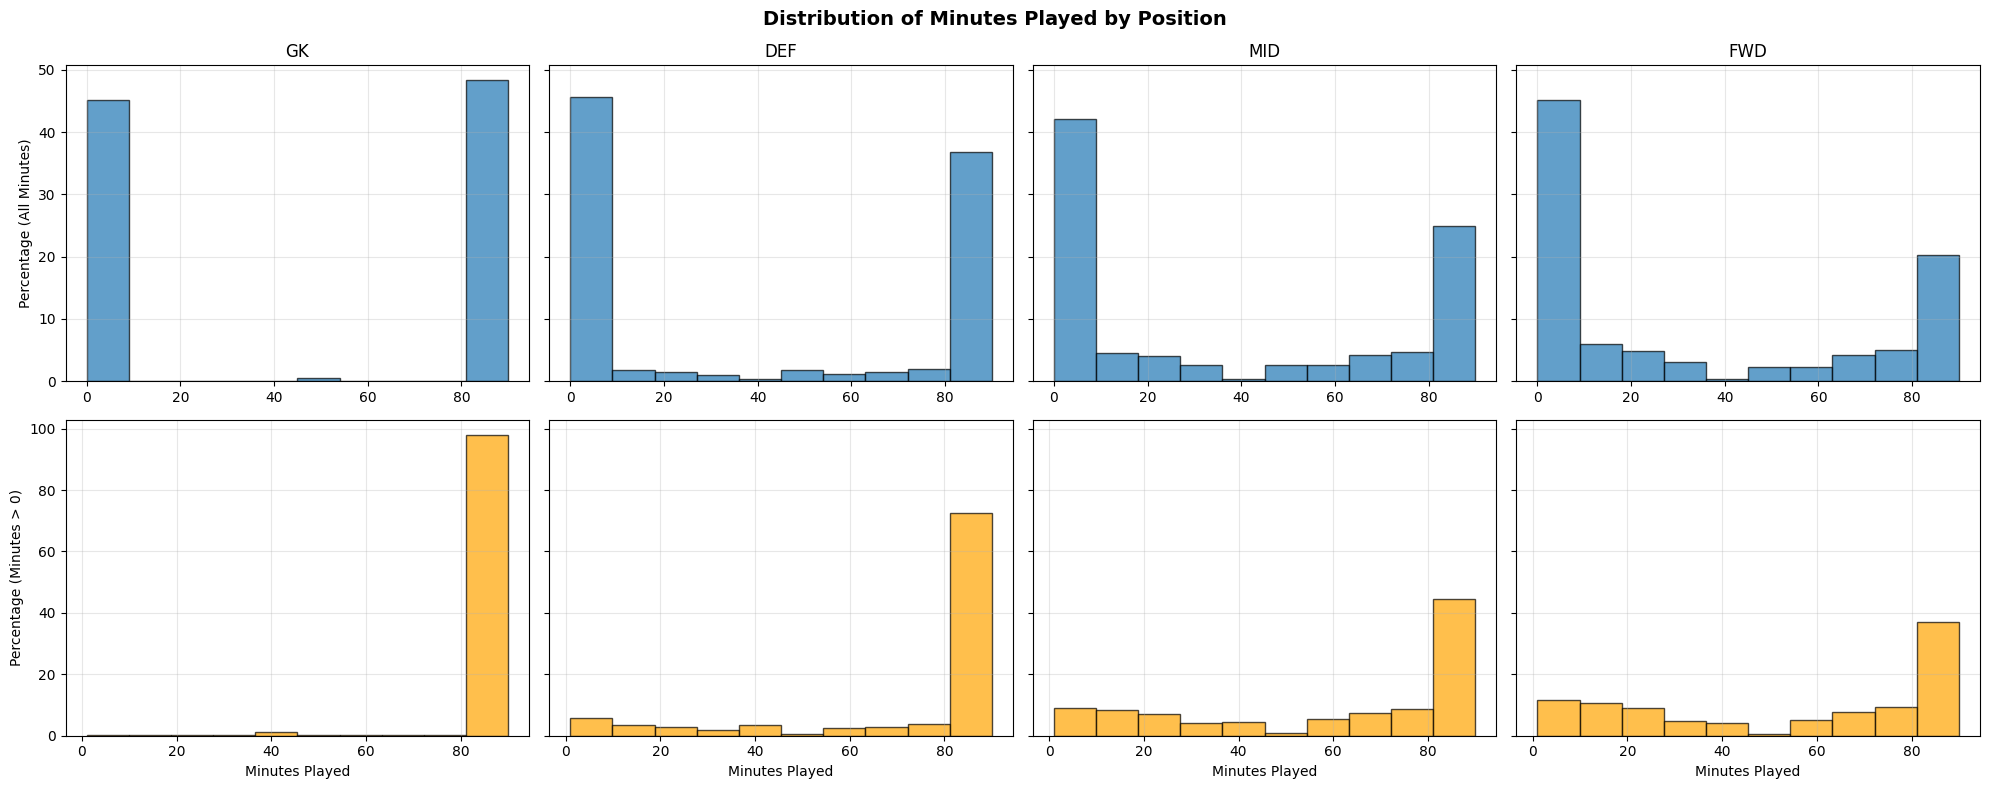

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Filter for specific positions
positions = ['GK', 'DEF', 'MID', 'FWD']
n_positions = len(positions)

# Create subplots with 2 rows
fig, axes = plt.subplots(2, n_positions, figsize=(5*n_positions, 8), sharey='row')

# Row 1: All data
for i, position in enumerate(positions):
    position_minutes = df[df['position'] == position]['minutes']
    axes[0, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, 
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[0, i].set_title(position)
    axes[0, i].grid(True, alpha=0.3)

axes[0, 0].set_ylabel('Percentage (All Minutes)')

# Row 2: Minutes > 0
for i, position in enumerate(positions):
    position_minutes = df[(df['position'] == position) & (df['minutes'] > 0)]['minutes']
    axes[1, i].hist(position_minutes, bins=10, edgecolor='black', alpha=0.7, color='orange',
                    weights=100*np.ones(len(position_minutes))/len(position_minutes))
    axes[1, i].set_xlabel('Minutes Played')
    axes[1, i].grid(True, alpha=0.3)

axes[1, 0].set_ylabel('Percentage (Minutes > 0)')

plt.suptitle('Distribution of Minutes Played by Position', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Goals conceded per 90
Estimated λ (mean goals per match): 1.350


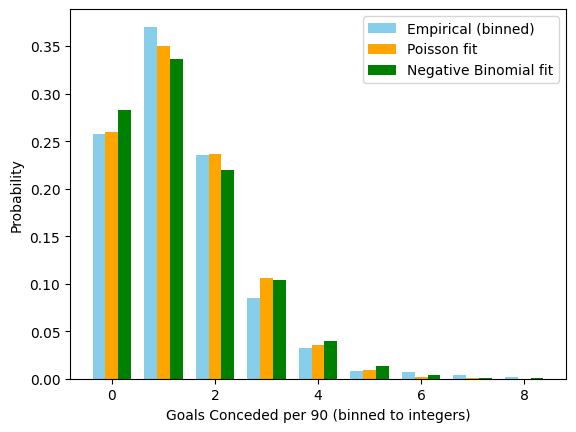

Mean: 1.342, Variance: 1.509
Overdispersion ratio (Var/Mean): 1.124
✅ Poisson assumption looks reasonable.
P(X < 1 goal) = 0.259


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Goals conceded per 90")

# Compute xGC per 90
data = df.copy()
data['xgc_p90'] = (data['expected_goals_conceded'] / data['minutes']) * 90

# Filter to reasonable samples
data = data[(data['minutes'] > 0) & (data['xgc_p90'] < 8)]['xgc_p90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean goals per match): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Goals Conceded per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")

# --- Example probability ---
p_less_than_1 = poisson.cdf(0, mu=lambda_hat)
print(f"P(X < 1 goal) = {p_less_than_1:.3f}")


Mids & Forwards
Estimated λ (mean defcon per 90): 8.264


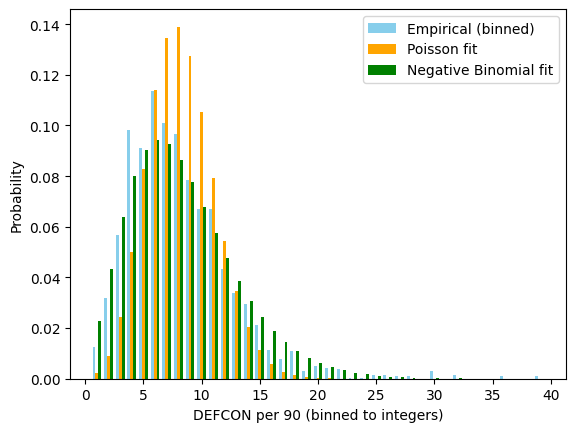

Mean: 8.256, Variance: 21.411
Overdispersion ratio (Var/Mean): 2.593
⚠️ Likely overdispersed → Negative Binomial may fit better.


In [20]:
#Test if defcon_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("Mids & Forwards")

# Filter to reasonable samples
data = df[(df['minutes'] > 0)
          & (df['defensive_contribution_per90'] > 0) 
          & (df['defensive_contribution_per90'] < 40)
          & (df['position'].isin(['DEF']))]['defensive_contribution_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean defcon per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('DEFCON per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


GK saves per 90
Estimated λ (mean saves per 90): 3.206


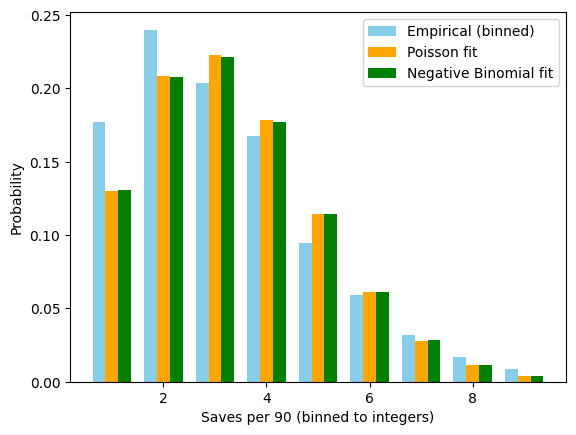

Mean: 3.206, Variance: 3.240
Overdispersion ratio (Var/Mean): 1.010
✅ Poisson assumption looks reasonable.


In [21]:
#Test if saves_p90 is neg binom distributed

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, nbinom
print("GK saves per 90")

# Filter to reasonable samples
data = df[#(df['minutes'] > 0)
          (df['saves_per90'] > 0) 
          & (df['saves_per90'] < 10)
          & (df['position'].isin(['GK']))]['saves_per90']

# Estimate λ
lambda_hat = np.mean(data)
print(f"Estimated λ (mean saves per 90): {lambda_hat:.3f}")

# --- BINNING into discrete Poisson-like counts ---
binned = np.round(data).astype(int)
binned = np.clip(binned, 0, None)

# Empirical frequencies
values, counts = np.unique(binned, return_counts=True)
prob_empirical = counts / counts.sum()

# --- Poisson PMF ---
poisson_pmf = poisson.pmf(values, mu=lambda_hat)

# --- Negative Binomial PMF (method of moments) ---
mean_val = np.mean(binned)
var_val = np.var(binned, ddof=1)

if var_val > mean_val:
    r = (mean_val ** 2) / (var_val - mean_val)
    p = r / (r + mean_val)
    negbin_pmf = nbinom.pmf(values, n=r, p=p)
else:
    negbin_pmf = np.zeros_like(values)
    print("Variance ≤ Mean → NB undefined, skipping NB plot.")

# --- Plot ---
plt.bar(values - 0.25, prob_empirical, width=0.25, label='Empirical (binned)', color='skyblue')
plt.bar(values, poisson_pmf, width=0.25, label='Poisson fit', color='orange')
plt.bar(values + 0.25, negbin_pmf, width=0.25, label='Negative Binomial fit', color='green')
plt.xlabel('Saves per 90 (binned to integers)')
plt.ylabel('Probability')
plt.legend()
plt.show()

# --- Dispersion diagnostics ---
overdispersion_ratio = var_val / mean_val
print(f"Mean: {mean_val:.3f}, Variance: {var_val:.3f}")
print(f"Overdispersion ratio (Var/Mean): {overdispersion_ratio:.3f}")

if overdispersion_ratio > 1.2:
    print("⚠️ Likely overdispersed → Negative Binomial may fit better.")
else:
    print("✅ Poisson assumption looks reasonable.")


In [22]:
#Create the data which the prediction data should be added to
prediction_data = df[(df['season']==20252026)
                     &(df['event']>=stats_current_gameweek+1)]

In [23]:
def predict_target_vectorized(df, model_dict, col_name):
    preds = []
    
    for pos, model in model_dict.items():
        subset = df[df['position'] == pos]
        if not subset.empty:
            pos_preds = model.predict_new(subset)
            temp = subset.copy()
            temp[col_name] = pos_preds
            preds.append(temp)
    
    if not preds:
        # If no positions matched at all
        return pd.Series(index=df.index, dtype=float)
    
    result = pd.concat(preds)
    
    # Safely align back to original DataFrame
    output = pd.Series(index=df.index, dtype=float)
    output.loc[result.index] = result[col_name]
    return output

In [24]:
target_col_name = 'mins_pred'
mins_model_dict = {'FWD': FWD_mins_predictor, 'MID': MID_mins_predictor, 'DEF': DEF_mins_predictor, 'GK': GK_mins_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\2521843321.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, mins_model_dict, col_name=target_col_name)


count    7440.000000
mean       60.570648
std        20.706240
min        14.339751
25%        43.264472
50%        61.971037
75%        79.821795
max        89.963486
Name: mins_pred, dtype: float64

In [25]:
target_col_name = 'xgp90_pred'
xg_model_dict = {'FWD': FWD_xG_predictor, 'MID': MID_xG_predictor, 'DEF': DEF_xG_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\365369552.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xg_model_dict, col_name=target_col_name)


count    6990.000000
mean        0.154136
std         0.130169
min         0.025164
25%         0.051419
50%         0.114440
75%         0.206964
max         0.747729
Name: xgp90_pred, dtype: float64

In [26]:
target_col_name = 'xap90_pred'
xA_model_dict = {'FWD': FWD_xA_predictor, 'MID': MID_xA_predictor, 'DEF': DEF_xA_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\4144355699.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xA_model_dict, col_name=target_col_name)


count    6990.000000
mean        0.099164
std         0.067756
min         0.026481
25%         0.048407
50%         0.078727
75%         0.129471
max         0.400732
Name: xap90_pred, dtype: float64

In [27]:
target_col_name = 'xgcp90_pred'
xGC_model_dict = {'FWD': FWD_xGC_predictor, 'MID': MID_xGC_predictor, 'DEF': DEF_xGC_predictor, 'GK':GK_xGC_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\682035545.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, xGC_model_dict, col_name=target_col_name)


count    7440.000000
mean        1.432835
std         0.343434
min         0.495780
25%         1.196047
50%         1.415458
75%         1.654329
max         2.583006
Name: xgcp90_pred, dtype: float64

In [28]:
target_col_name = 'xbpsp90_pred'
bps_model_dict = {'FWD': FWD_bps_predictor, 'MID': MID_bps_predictor, 'DEF': DEF_bps_predictor, 'GK':GK_bps_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\3051138591.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, bps_model_dict, col_name=target_col_name)


count    7440.000000
mean       15.588644
std         3.249914
min         5.697375
25%        13.405581
50%        15.287312
75%        17.510180
max        44.074325
Name: xbpsp90_pred, dtype: float64

                                 OLS Regression Results                                
Dep. Variable:                  bonus   R-squared (uncentered):                   0.448
Model:                            OLS   Adj. R-squared (uncentered):              0.448
Method:                 Least Squares   F-statistic:                          3.389e+04
Date:                Tue, 27 Jan 2026   Prob (F-statistic):                        0.00
Time:                        10:59:53   Log-Likelihood:                         -39436.
No. Observations:               41837   AIC:                                  7.887e+04
Df Residuals:                   41836   BIC:                                  7.888e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

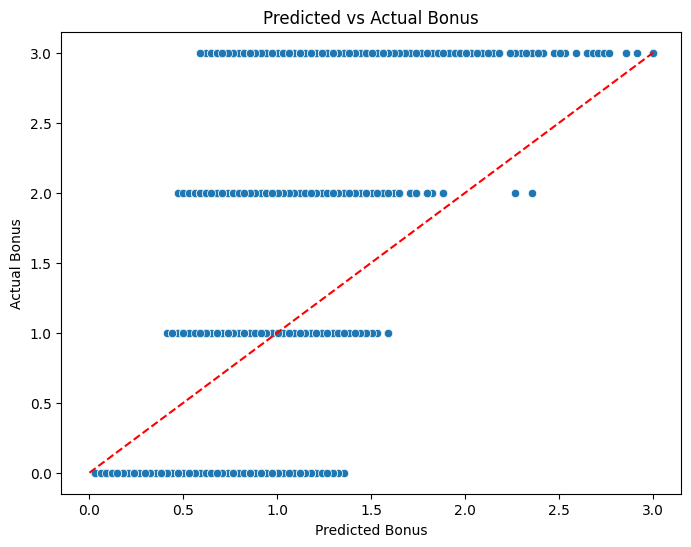

Actual Bonus       0.0       1.0       2.0       3.0
Position                                            
DEF           0.459193  0.230421  1.106753  1.947843
FWD           0.332639  0.198217  1.047682  1.709120
GK            0.489982  0.245185  1.115174  2.012079
GKP                NaN       NaN       NaN       NaN
MID           0.396003  0.245542  1.049887  1.824247


C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\3541705010.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))


In [29]:
# Generalize the relationship between bps & bonus points
import statsmodels.formula.api as smf
dfb=df.copy()
filtered = (dfb['minutes']>45) & (dfb['bonus']>=0) & (dfb['bps']>0) & (dfb['position'].isin(['GK','DEF','MID','FWD']))
# df['bonus_sq'] = df['bonus']**2

model = smf.ols('bonus ~ bps -1', data=dfb[filtered]).fit()
print(model.summary())

dfb['bonus_pred'] = model.predict(dfb[filtered])
dfb['bonus_pred'] = np.clip(dfb['bonus_pred'], 0, 3) # clip prediction to 3

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x='bonus_pred', y='bonus', data=dfb)
plt.plot([dfb['bonus'].min(), dfb['bonus'].max()],
         [dfb['bonus'].min(), dfb['bonus'].max()],
         color='red', linestyle='--')  # 45-degree line
plt.xlabel('Predicted Bonus')
plt.ylabel('Actual Bonus')
plt.title('Predicted vs Actual Bonus')
plt.show()

import pandas as pd
import numpy as np

# Function to calculate RMSE
def rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

# Group by position and actual bonus, then calculate RMSE
rmse_table = dfb.groupby(['position', 'bonus']).apply(lambda x: rmse(x['bonus'], x['bonus_pred']))

# Convert to DataFrame
rmse_table = rmse_table.reset_index()
rmse_table.columns = ['Position', 'Actual Bonus', 'RMSE']

pivot_rmse = rmse_table.pivot(index='Position', columns='Actual Bonus', values='RMSE')
print(pivot_rmse)


In [30]:
#Add bonus prediction to data
prediction_data['bonus_pred'] = model.predict(prediction_data)
print("bonus_pred added to prediction data")

bonus_pred added to prediction data


C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\2545047019.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['bonus_pred'] = model.predict(prediction_data)


In [31]:
target_col_name = 'xsavesp90_pred'
saves_model_dict = {'GK':GK_saves_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\803536942.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, saves_model_dict, col_name=target_col_name)


count    450.000000
mean       3.037775
std        0.684635
min        1.112318
25%        2.688913
50%        2.950136
75%        3.390151
max        5.147535
Name: xsavesp90_pred, dtype: float64

In [32]:
target_col_name = 'xdefconp90_pred'
defcon_model_dict = {'FWD': FWD_defcon_predictor, 'MID': MID_defcon_predictor, 'DEF': DEF_defcon_predictor}
prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)
prediction_data[target_col_name].describe()

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\2777375241.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data[target_col_name] = predict_target_vectorized(prediction_data, defcon_model_dict, col_name=target_col_name)


count    6990.000000
mean        7.948035
std         1.967831
min         2.844953
25%         6.674747
50%         8.021534
75%         9.457970
max        12.876661
Name: xdefconp90_pred, dtype: float64

In [33]:
prediction_data[prediction_data['position']=='MID'].head()[["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]]

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
129180,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,24.0,Wolves,915.716268,38.873708,0.156486,0.351089,1.712816
129183,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,25.0,Aston Villa,1177.298455,37.769607,0.118650,0.134610,1.770308
129259,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,26.0,Everton,1061.389703,36.930412,0.121808,0.173212,1.994389
129262,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,27.0,West Ham,971.988000,37.230412,0.125674,0.346864,1.726725
129458,Ben Winterburn,96.0,45.0,Bournemouth,MID,20252026.0,28.0,Sunderland,1043.082494,37.650412,0.121808,0.173212,1.836192


In [34]:
prediction_data[
    (prediction_data['event']==picks_current_gameweek+1)
    &(prediction_data['mins_pred']>0)
    ][["player_name_id","element","value","team_name","position","season","event","opp_team_name","opp_team_elo"
    ,'mins_pred','xgp90_pred','xap90_pred','xgcp90_pred'
    ]].sort_values(by='xgp90_pred',ascending=False
        ).head(10)

,player_name_id,element,value,team_name,position,season,event,opp_team_name,opp_team_elo,mins_pred,xgp90_pred,xap90_pred,xgcp90_pred
135377,Fábio Freitas Gouveia Carvalho,123.0,47.0,Brentford,MID,20252026.0,24.0,Aston Villa,1177.298455,40.589338,0.662740,0.154459,1.719847
145535,Rodrigo Muniz Carvalho,338.0,53.0,Fulham,FWD,20252026.0,24.0,Man Utd,1082.944419,36.305274,0.658011,0.256408,1.249800
147879,William Osula,500.0,54.0,Newcastle,FWD,20252026.0,24.0,Liverpool,1169.484614,40.008492,0.645582,0.253080,1.470270
130208,Alexander Isak,499.0,103.0,Liverpool,FWD,20252026.0,24.0,Newcastle,1094.605299,36.301144,0.643443,0.296188,1.496344
139474,Kai Havertz,30.0,73.0,Arsenal,FWD,20252026.0,24.0,Leeds,975.315179,43.149300,0.610763,0.227357,1.117008
134100,Eddie Nketiah,284.0,54.0,Crystal Palace,FWD,20252026.0,24.0,Nott'm Forest,1031.482845,37.033463,0.574044,0.314302,1.473920
134475,Enes Ünal,98.0,54.0,Bournemouth,FWD,20252026.0,24.0,Wolves,915.716268,17.654365,0.542036,0.040084,1.119171
132561,Chris Wood,525.0,72.0,Nott'm Forest,FWD,20252026.0,24.0,Crystal Palace,1048.207524,35.007620,0.536529,0.272941,1.348598
135294,Frank Onyeka,128.0,48.0,Brentford,MID,20252026.0,24.0,Aston Villa,1177.298455,33.027974,0.531596,0.120173,1.683120
134838,Ethan Nwaneri,25.0,50.0,Arsenal,MID,20252026.0,24.0,Leeds,975.315179,31.924903,0.524649,0.317567,0.920259


In [35]:
import pandas as pd
from scipy.stats import nbinom

def calculate_negbinom_parameters(position_list, df):

    # 1. Calculate mean and variance
    filtered = (df['minutes'] > 0) & (df['defensive_contribution_per90'] > 0) & (df['defensive_contribution_per90'] < 40) & (df['position'].isin(position_list))
    mean = df[filtered]['defensive_contribution_per90'].mean()
    variance = df[filtered]['defensive_contribution_per90'].var()
    # r = number of successes
    r = (mean**2) / (variance - mean)
    # p = success probability
    p = r / (r + mean)
    return r,p

In [36]:
from scipy.stats import poisson
import numpy as np

def expected_score(mu, max_events=10, rule=None, points_per_n=None, points_value=None):
    """
    Calculate the expected score given an average event rate (mu)
    using a Poisson model.

    Parameters
    ----------
    mu : float
        Expected number of events (e.g., goals conceded, shots saved).
    max_events : int
        Maximum number of discrete events to sum over.
    rule : callable, optional
        Function that maps event count -> points. Example: lambda k: -np.floor(k / 2)
    points_per_n : int, optional
        For simple rules: number of events required for one point (e.g. 3 shots saved = 1 pt)
    points_value : float, optional
        Value of that one point (e.g. +1 for shots saved, -1 for goals conceded)

    Returns
    -------
    float
        Expected points based on Poisson-distributed event counts.
    """
    array = np.arange(0, max_events + 1)
    probs = poisson.pmf(array, mu)

    if rule is not None:
        scores = np.array([rule(k) for k in array])
    elif points_per_n is not None and points_value is not None:
        # General simple rule: 1 point_value for every n events
        scores = np.floor(array / points_per_n) * points_value
    else:
        raise ValueError("You must provide either a rule function or both points_per_n and points_value.")

    return np.sum(scores * probs)


In [37]:
from scipy.stats import norm
import numpy as np

scoring_dict = {
    "FWD": {'xgp90_pred': 4, 'xap90_pred': 3, 'xgcp90_pred': 0, 'xgc_ss':0, 'defcon':2},
    "MID": {'xgp90_pred': 5, 'xap90_pred': 3, 'xgcp90_pred': 1, 'xgc_ss':0, 'defcon':2},
    "DEF": {'xgp90_pred': 6, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2},
    "GK":  {'xgp90_pred': 10, 'xap90_pred': 3, 'xgcp90_pred': 4, 'xgc_ss':-1, 'defcon':2}
}

def scoring(x, scoring_dict, points_type, negbinom_rp_dict=None):
    mins_factor = x['mins_pred']/90
    if points_type == 'mins':
        if pd.isna(x['mins_pred']):
            return 0
        elif x['mins_pred'] > 0:
            return 1 + 1 / (1 + np.exp(-(x['mins_pred'] - 60) / 10)) #smooth logistic approximation from 1 to 2 points, 10 is a scale factor
        
    if points_type == 'goals':
        goals_points = mins_factor * x['xgp90_pred'] * scoring_dict[x['position']]['xgp90_pred']
        return goals_points
    if points_type == 'assists':
        assist_points = mins_factor * x['xap90_pred'] * scoring_dict[x['position']]['xap90_pred']
        return assist_points
    if points_type == 'clean_sheets':
        p_less_than_1 = poisson.cdf(0, mu=x['xgcp90_pred'])
        cs_points = p_less_than_1 * scoring_dict[x['position']]['xgcp90_pred']
        return cs_points
    
    if points_type == 'shots_saved': 
        if x['position'] == 'GK':
            saves_points = expected_score(mu=x['xsavesp90_pred'],  # expected shots saved per 90
                                   max_events=15,
                                   points_per_n=3, #for every 3 shots saved
                                   points_value=1) #scores 1 point
            return saves_points
        else:
            return 0
        
    if points_type == 'goals_conceded':
        if x['position'] in ['DEF','GK']:
            gc_points = expected_score(mu=x['xgcp90_pred'], 
                                   max_events=10, 
                                   points_per_n=2, #for every 2 goals conceded 
                                   points_value=-1) #scores -1 points 
            return gc_points
        else:
            return 0

    if points_type == 'defcon':
        pos = x['position']
        if pos in ['MID','FWD']:
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 12
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        elif pos == 'DEF':
            r = negbinom_rp_dict[pos]['r']
            p = negbinom_rp_dict[pos]['p']
            k = 10
            prob_more_than_12 = 1 - nbinom.cdf(k, r, p)
            defcon_points = prob_more_than_12 * scoring_dict[pos]['defcon']
            return defcon_points
        else: return 0

    if points_type == 'bonus':
        return x['xbpsp90_pred']*0.0294 # ols regression coefficient

prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
prediction_data['xpoints_assists'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='assists'), axis=1)
prediction_data['xpoints_clean_sheets'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='clean_sheets'), axis=1)

prediction_data['xpoints_shots_saved'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='shots_saved'), axis=1)
prediction_data['xpoints_goals_conceded'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals_conceded'), axis=1)

def_r,def_p = calculate_negbinom_parameters(['DEF'], df)
mid_r,mid_p = calculate_negbinom_parameters(['MID'], df)
fwd_r,fwd_p = calculate_negbinom_parameters(['FWD'], df)
rp_dict = {'DEF':{'r':def_r,'p':def_p},'MID':{'r':mid_r,'p':mid_p},'FWD':{'r':fwd_r,'p':fwd_p}}
prediction_data['xpoints_defcon'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='defcon', negbinom_rp_dict=rp_dict), axis=1)
prediction_data['xpoints_bonus'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='bonus'), axis=1)

prediction_data['xpoints'] = prediction_data[['xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets',
                                              'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus']].sum(axis=1, skipna=True)

C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\3158721815.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_mins'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='mins'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykernel_17520\3158721815.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['xpoints_goals'] = prediction_data.apply(lambda x: scoring(x, scoring_dict, points_type='goals'), axis=1)
C:\Users\Chris\AppData\Local\Temp\ipykerne

In [38]:
predictions = prediction_data[['player_name_id', 'team_name','team_elo','element','position','opp_team_name','opp_team_elo', 'season', 'value', 'event',
                       'mins_pred', 'xgp90_pred', 'xap90_pred', 'xgcp90_pred',
                       'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets','xpoints_shots_saved',
                       'xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                       'xpoints']]

In [39]:
table_name = "predictions"
if __name__ == "__main__":
    db_creator.create_staging_table_then_insert_data(table_name, data=predictions)
    preds = db_creator.table_to_df(table_name=table_name)
    print(preds.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7440 entries, 0 to 7439
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_name_id          7440 non-null   object 
 1   team_name               7440 non-null   object 
 2   team_elo                7440 non-null   float64
 3   element                 7440 non-null   float64
 4   position                7440 non-null   object 
 5   opp_team_name           7440 non-null   object 
 6   opp_team_elo            7440 non-null   float64
 7   season                  7440 non-null   float64
 8   value                   7440 non-null   float64
 9   event                   7440 non-null   float64
 10  mins_pred               7440 non-null   float64
 11  xgp90_pred              6990 non-null   float64
 12  xap90_pred              6990 non-null   float64
 13  xgcp90_pred             7440 non-null   float64
 14  xpoints_mins            7440 non-null   

In [40]:
# Add new columns to the xPoints table
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS in_any_team INTEGER DEFAULT 0,
    ADD COLUMN IF NOT EXISTS in_my_team INTEGER DEFAULT 0
""")

In [41]:
current_gameweek = picks_current_gameweek
my_name = "Christopher Harris"

# Get the player lists
view = db_creator.run_sql(f"""
    WITH 
    current_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
    ),
    my_players AS (
        SELECT element
        FROM fpl_picks
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
    SELECT * FROM my_players
""")

# Update the flags
db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_any_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
    )
""")

db_creator.execute_sql(f"""
    UPDATE predictions
    SET in_my_team = 1
    WHERE element IN (
        SELECT element 
        FROM fpl_picks 
        WHERE gw = {current_gameweek}
        AND member = '{my_name}'
    )
""")

In [42]:
print(f"Gameweek {picks_current_gameweek+1} Predictions")
prediction_data[
    prediction_data['event']==picks_current_gameweek+1
][["player_name_id","element",'event',"value","team_name","position","opp_team_name","opp_team_elo"
   ,'mins_pred', 'xpoints_mins', 'xpoints_goals', 'xpoints_assists', 'xpoints_clean_sheets', 
   'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
   'xpoints'
   ]].sort_values(by='xpoints',ascending=False
    ).head(10)

Gameweek 24 Predictions


,player_name_id,element,event,value,team_name,position,opp_team_name,opp_team_elo,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
135599,Gabriel dos Santos Magalhães,5.0,24.0,69.0,Arsenal,DEF,Leeds,975.315179,81.930082,1.899620,0.366580,0.548755,2.235067,0.0,-0.119067,0.547513,0.631643,6.110113
145042,Riccardo Calafiori,7.0,24.0,56.0,Arsenal,DEF,Leeds,975.315179,67.230270,1.673273,1.192057,0.248718,1.765187,0.0,-0.207705,0.547513,0.557569,5.776612
139412,Jurriën Timber,8.0,24.0,63.0,Arsenal,DEF,Leeds,975.315179,85.527442,1.927758,0.308611,0.249628,2.227363,0.0,-0.120256,0.547513,0.510750,5.651368
147926,William Saliba,6.0,24.0,60.0,Arsenal,DEF,Leeds,975.315179,86.525050,1.934165,0.257009,0.137186,2.113827,0.0,-0.138714,0.547513,0.551825,5.402811
147177,Trai Hume,532.0,24.0,45.0,Sunderland,DEF,Burnley,889.643897,73.645824,1.796503,0.262627,0.756989,1.488947,0.0,-0.278753,0.547513,0.675227,5.249054
138404,John Stones,409.0,24.0,54.0,Man City,DEF,Spurs,990.668127,62.147234,1.553476,1.244382,0.290452,1.271362,0.0,-0.348358,0.547513,0.616245,5.175072
133541,Declan Rice,21.0,24.0,74.0,Arsenal,MID,Leeds,975.315179,85.447799,1.927222,0.870848,0.650270,0.558686,0.0,0.000000,0.514732,0.639160,5.160918
141895,Matheus Nunes,407.0,24.0,55.0,Man City,DEF,Spurs,990.668127,65.905822,1.643499,0.183371,0.270837,1.927910,0.0,-0.173004,0.547513,0.724297,5.124422
143550,Nico O'Reilly,411.0,24.0,51.0,Man City,DEF,Spurs,990.668127,77.669247,1.854075,0.249715,0.135114,1.890487,0.0,-0.180573,0.547513,0.602694,5.099026
139222,Joško Gvardiol,403.0,24.0,60.0,Man City,DEF,Spurs,990.668127,58.624937,1.465677,0.591692,0.220587,1.811160,0.0,-0.197418,0.547513,0.629655,5.068866


In [43]:
current_gameweek=picks_current_gameweek
print(f"Next 5 GWs: GW{current_gameweek+1} - GW{current_gameweek+5}")
next_5_gws_filter = (prediction_data['event']>=current_gameweek)&(prediction_data['event']<=current_gameweek+5)
prediction_data[next_5_gws_filter].groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Next 5 GWs: GW24 - GW28


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
405,Riccardo Calafiori,339.580208,8.440557,6.061537,1.250797,7.629182,0.0,-1.369666,2.737565,2.489979,27.239950
153,Gabriel dos Santos Magalhães,410.626124,9.506825,1.761442,2.271905,9.009596,0.0,-1.061045,2.737565,2.611030,26.837317
100,Declan Rice,427.648796,9.638828,4.321509,3.164890,2.298622,0.0,0.000000,2.573661,3.186912,25.184421
254,Jurriën Timber,427.637209,9.638788,1.559654,1.184214,8.916102,0.0,-1.076844,2.737565,2.131983,25.091462
27,Antoine Semenyo,426.805817,9.633175,5.085814,2.765846,1.373036,0.0,0.000000,2.573661,2.795082,24.226614
348,Morgan Rogers,429.231602,9.649330,4.836576,2.489123,1.622949,0.0,0.000000,2.573661,2.976523,24.148160
231,John Stones,306.534018,7.662898,6.166760,1.408923,4.934954,0.0,-2.394892,2.737565,3.141043,23.657249
480,William Saliba,432.625249,9.670826,1.247172,0.676956,8.112826,0.0,-1.295181,2.737565,2.417466,23.567631
318,Matheus Nunes,329.809112,8.223891,0.854491,1.200929,8.363080,0.0,-1.174536,2.737565,3.330736,23.536155
58,Bruno Borges Fernandes,384.170726,9.216781,4.765938,2.673665,1.316609,0.0,0.000000,2.573661,2.892360,23.439012


In [44]:
print("Rest of Season Predictions")
prediction_data.groupby('player_name_id')[['mins_pred', 'xpoints_mins', 'xpoints_goals', 
                                           'xpoints_assists', 'xpoints_clean_sheets', 
                                           'xpoints_shots_saved','xpoints_goals_conceded','xpoints_defcon','xpoints_bonus',
                                           'xpoints'
                                           ]].agg('sum').reset_index().sort_values(by='xpoints',ascending=False).head(10)

Rest of Season Predictions


,player_name_id,mins_pred,xpoints_mins,xpoints_goals,xpoints_assists,xpoints_clean_sheets,xpoints_shots_saved,xpoints_goals_conceded,xpoints_defcon,xpoints_bonus,xpoints
405,Riccardo Calafiori,1017.720482,25.298953,18.243762,3.764888,22.240631,0.0,-4.304904,8.212694,7.415537,80.871563
153,Gabriel dos Santos Magalhães,1229.445953,28.497498,5.648340,6.768809,26.256294,0.0,-3.377161,8.212694,7.559796,79.566271
100,Declan Rice,1282.482588,28.913413,13.064968,9.405393,6.734629,0.0,0.000000,7.720982,9.576709,75.416093
254,Jurriën Timber,1281.115861,28.903737,4.829380,3.652036,25.972122,0.0,-3.440018,8.212694,6.273549,74.403500
27,Antoine Semenyo,1280.399672,28.899404,15.514638,8.141232,4.231335,0.0,0.000000,7.720982,8.341822,72.849413
348,Morgan Rogers,1287.533468,28.946934,14.400338,7.160277,4.798171,0.0,0.000000,7.720982,8.623824,71.650526
231,John Stones,920.956086,23.022364,18.546931,4.228973,14.186413,0.0,-7.431772,8.212694,9.348360,70.113965
168,Harry Wilson,1286.510769,28.939850,14.901709,6.609142,4.164787,0.0,0.000000,7.720982,7.761148,70.097618
318,Matheus Nunes,988.491155,24.650085,2.554999,3.549727,24.807515,0.0,-3.597253,8.212694,9.732096,69.909863
480,William Saliba,1297.261866,29.008624,3.733915,2.042651,23.730016,0.0,-4.104591,8.212694,7.109038,69.732348


In [45]:
from datetime import datetime

# Add the columns
db_creator.execute_sql("""
    ALTER TABLE predictions
    ADD COLUMN IF NOT EXISTS prediction_timestamp TIMESTAMP,
    ADD COLUMN IF NOT EXISTS prediction_gameweek INTEGER;
""")

# Update ALL existing rows with current timestamp and gameweek
db_creator.execute_sql("""
    UPDATE predictions
    SET prediction_timestamp = :timestamp,
        prediction_gameweek = :gameweek;
""", params={
    'timestamp': datetime.now(),
    'gameweek': stats_current_gameweek
})

In [46]:
# ## Reset predictions table

# db_creator.execute_sql("""
#     DROP TABLE IF EXISTS predictions_allgws
# """)

In [47]:
# Create predictions_allgws if it doesn't exist
db_creator.execute_sql("""
    CREATE TABLE IF NOT EXISTS predictions_allgws AS
    SELECT p.*,
            -- pg.player_name_id, pg.team_name, pg.team_elo, pg.element, pg.position, pg.opp_team_name, pg.opp_team_elo, pg.value -- these are in both tables
            pg.fixture, pg.total_points
            
    FROM predictions p
    LEFT JOIN playergw pg 
        ON p.player_name_id = pg.player_name_id 
        AND p.event = pg.event
        AND p.season = pg.season
    WHERE 1=0;  -- Empty table with correct schema
""")

In [48]:
# Step 1: Insert new predictions with current timestamp
# This will create NEW rows even for gameweeks that already have predictions
db_creator.execute_sql("""
INSERT INTO predictions_allgws (
    player_name_id, team_name, team_elo, element, position, opp_team_name, opp_team_elo, value, 
    event, season, xpoints, 
    prediction_timestamp, prediction_gameweek,
    fixture, total_points
)
SELECT 
    p.player_name_id, p.team_name, p.team_elo, p.element, p.position, p.opp_team_name, 
    p.opp_team_elo, p.value, p.event, p.season, p.xpoints, 
    p.prediction_timestamp, p.prediction_gameweek,
    pg.fixture, pg.total_points
FROM predictions p
LEFT JOIN playergw pg 
    ON p.player_name_id = pg.player_name_id 
    AND p.event = pg.event 
    AND p.season = pg.season;
""")

print(f"Successfully added {db_creator.run_sql('SELECT COUNT(*) FROM predictions').iloc[0,0]} new predictions to predictions_allgws")

Successfully added 7440 new predictions to predictions_allgws


In [49]:
view = db_creator.table_to_df('predictions_allgws')
future_filter = (
    view['prediction_gameweek']==stats_current_gameweek) & (
    view['event']==stats_current_gameweek+1) & (
    view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points']][future_filter].head()

,player_name_id,event,season,total_points
5663,Erling Haaland,24.0,20252026.0,NaN
19365,Erling Haaland,24.0,20252026.0,NaN


In [50]:
view = db_creator.table_to_df('playergw')
future_filter = (view['season']==20252026)&(view['event']>=13)&(view['player_name_id']=='Erling Haaland')
view[['player_name_id','event','season','total_points','minutes']][future_filter].head(10)

,player_name_id,event,season,total_points,minutes
180349,Erling Haaland,13.0,20252026.0,2.0,90.0
180350,Erling Haaland,14.0,20252026.0,14.0,90.0
180351,Erling Haaland,15.0,20252026.0,2.0,68.0
180352,Erling Haaland,16.0,20252026.0,13.0,90.0
180353,Erling Haaland,17.0,20252026.0,16.0,90.0
180354,Erling Haaland,18.0,20252026.0,2.0,90.0
180355,Erling Haaland,19.0,20252026.0,2.0,90.0
180356,Erling Haaland,20.0,20252026.0,2.0,90.0
180357,Erling Haaland,21.0,20252026.0,6.0,90.0
180358,Erling Haaland,22.0,20252026.0,2.0,79.0


In [51]:
view = db_creator.table_to_df('predictions_allgws')
view[['player_name_id','prediction_timestamp','event','xpoints','total_points']][
    (view['season']==20252026)&(
    view['event']>=20)&(view['player_name_id']=='Erling Haaland')].sort_values(by='event')

,player_name_id,prediction_timestamp,event,xpoints,total_points
1615,Erling Haaland,2026-01-05 18:33:33.065519,21.0,5.628327,6.0
13463,Erling Haaland,2026-01-05 18:33:33.065519,22.0,5.571476,2.0
13479,Erling Haaland,2026-01-05 18:33:33.065519,23.0,7.368988,1.0
13464,Erling Haaland,2026-01-05 18:33:33.065519,24.0,5.915376,NaN
5663,Erling Haaland,2026-01-26 14:27:00.627006,24.0,4.148815,NaN
19365,Erling Haaland,2026-01-27 11:00:04.422834,24.0,3.886675,NaN
16890,Erling Haaland,2026-01-26 14:27:00.627006,25.0,3.537848,NaN
13465,Erling Haaland,2026-01-05 18:33:33.065519,25.0,4.491019,NaN
23174,Erling Haaland,2026-01-27 11:00:04.422834,25.0,3.494566,NaN
23175,Erling Haaland,2026-01-27 11:00:04.422834,26.0,3.711646,NaN


In [52]:
# Get the data from the predictions table
df_preds = db_creator.table_to_df('predictions_allgws')

# Remove rows where actual_points is missing
gw_filter=(df_preds['prediction_gameweek']>=13)&(
            df_preds['event']>=stats_current_gameweek)&(
                df_preds['event']<=stats_current_gameweek+5)&(
            df_preds['season']==20252026)#&(
            #df_preds['player_name_id']=='Erling Haaland')
df_complete = df_preds[gw_filter]

df_complete.pivot_table(index=['prediction_timestamp','prediction_gameweek','season','event'], values=['xpoints','total_points'])

total_points  \
prediction_timestamp       prediction_gameweek season     event                 
2026-01-05 18:33:33.065519 20                  20252026.0 23.0       0.857732   
                                                          24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-07 16:29:20.849190 21                  20252026.0 23.0       3.000000   
                                                          24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-08 16:44:49.940956 21                  20252026.0 23.0       0.000000   
                                                          24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-22 16:59:38.976316 23                  20252026.0 24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-23 11:49:44.805713 22                  20252026.0 23.0       2.000000   
2026-01-25 11:24:25.347489 23                  20252026.0 24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-26 14:27:00.627006 23                  20252026.0 24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   
2026-01-27 11:00:04.422834 23                  20252026.0 24.0            NaN   
                                                          25.0            NaN   
                                                          26.0            NaN   
                                                          27.0            NaN   
                                                          28.0            NaN   

                                                                  xpoints  
prediction_timestamp       prediction_gameweek season     event            
2026-01-05 18:33:33.065519 20                  20252026.0 23.0   3.414770  
                                                          24.0   3.426012  
                                                          25.0   3.409847  
                                                          26.0   3.426947  
                                                          27.0   3.437517  
                                                          28.0   3.421395  
2026-01-07 16:29:20.849190 21                  20252026.0 23.0   3.041140  
                                                          2

In [53]:
#Future GWs should show more than one row here when more predictions are added...
df_complete.pivot_table(index='prediction_timestamp',values='player_name_id',aggfunc='count',dropna=False)

,player_name_id
prediction_timestamp,
2026-01-05 18:33:33.065519,2910
2026-01-07 16:29:20.849190,12
2026-01-08 16:44:49.940956,12
2026-01-22 16:59:38.976316,15
2026-01-23 11:49:44.805713,3
2026-01-25 11:24:25.347489,5
2026-01-26 14:27:00.627006,2475
2026-01-27 11:00:04.422834,2480


In [54]:
filtered = df_complete['prediction_gameweek']==21
df_complete[filtered][['prediction_timestamp','player_name_id','event']].describe()

,prediction_timestamp,event
count,24,24.000000
mean,2026-01-08 04:37:05.395073024,25.500000
min,2026-01-07 16:29:20.849190,23.000000
25%,2026-01-07 16:29:20.849189888,24.000000
50%,2026-01-08 04:37:05.395073024,25.500000
75%,2026-01-08 16:44:49.940955904,27.000000
max,2026-01-08 16:44:49.940956,28.000000
std,NaN,1.744557


In [55]:
# # Create the plot
# plt.figure(figsize=(10, 8))
# sns.scatterplot(data=df_complete, x='xpoints', y='total_points', alpha=0.6)

# # Add a diagonal reference line (perfect predictions)
# max_val = max(df_complete['xpoints'].max(), df_complete['total_points'].max())
# plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction', linewidth=2)

# # Add regression line showing actual correlation
# from scipy.stats import linregress
# slope, intercept, r_value, p_value, std_err = linregress(df_complete['xpoints'], df_complete['total_points'])
# x_line = np.array([df_complete['xpoints'].min(), df_complete['xpoints'].max()])
# y_line = slope * x_line + intercept
# plt.plot(x_line, y_line, 'g-', label=f'Best fit (y={slope:.2f}x+{intercept:.2f})', linewidth=2)

# print(f"Correlation: {df_complete['xpoints'].corr(df_complete['total_points']):.3f}")
# print(f"Mean Absolute Error: {(df_complete['xpoints'] - df_complete['total_points']).abs().mean():.3f}")
# print(f"Root Mean Squared Error: {((df_complete['xpoints'] - df_complete['total_points'])**2).mean()**0.5:.3f}")

# plt.xlabel('Predicted Points (xPoints)', fontsize=12)
# plt.ylabel('Actual Points', fontsize=12)
# plt.title(f'Predicted vs Actual Points in GW{stats_current_gameweek}', fontsize=14, fontweight='bold')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

In [56]:
finish=time.perf_counter()
print(f'Finished in {round(((finish-start)/60),2)} minute(s)')
#10/11/25: Finished in 8.91 minute(s)

Finished in 30.23 minute(s)


In [57]:
# Notification when file has finished running
from plyer import notification

notification.notify(
    title='Script Complete',
    message='Your file has finished running!',
    app_name='Jupyter Notebook',
    timeout=20  # notification stays for 20 seconds
)